In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
from numba import cuda
from IPython import get_ipython
from IPython.display import display
import math
from __future__ import print_function, absolute_import

from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32
import time

@cuda.jit
def get_randoms(xor,xor_out,lx,ly):
    me,x,y = cuda.grid(3)
    thread_id = x + lx*y + me+lx*ly
    xor_out[me][x][y] = cuda.random.xoroshiro128p_uniform_float32(xor, thread_id)

lx,ly = 6,6


# Configura las dimensiones de tus hilos y bloques
threads_per_block = (4, 16,16)

# Calcula el número de bloques en la cuadrícula
blocks_per_grid_x = math.ceil(lx / threads_per_block[1])
blocks_per_grid_y = math.ceil(ly / threads_per_block[2])
blocks_per_grid = (1, blocks_per_grid_x, blocks_per_grid_y)  # solo necesitas un bloque en la dimensión x porque `me` solo varía de 0 a 3
threads = threads_per_block
blocks = blocks_per_grid

# Calcula el número total de threads
total_threads = threads_per_block[0] * blocks_per_grid[0] * threads_per_block[1] * blocks_per_grid[1] * threads_per_block[2] * blocks_per_grid[2]
    

xor_out = cuda.to_device(np.zeros((4,lx,ly), dtype=float))
xor = cuda.to_device(cuda.random.create_xoroshiro128p_states(total_threads, seed = time.time()))
get_randoms[threads,blocks](xor,xor_out,lx,ly)
xor_host = xor_out.copy_to_host()
cuda.synchronize()
print(xor_host)

AttributeError: partially initialized module 'numba' has no attribute 'core' (most likely due to a circular import)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
def primeros_vecinos(me,x,y,lx,ly,k):
    f = [0,0,0,0]
    if me == 0:
        f[0] = [(me+3)%4,x,(y+1)%ly,k-1] #D_i-1
        f[1] = [(me+1)%4,x,y,k] #B_i
        f[2] = [(me+3)%4,x,y,k-1] #D_i-1
        f[3] = [(me+1)%4,(x+1)%lx,y,k] #B_i
    if me == 1:
        f[0] = [(me+1)%4,x,(y+1)%ly,k] 
        f[1] = [(me+3)%4,(x+lx-1)%lx,y,k] 
        f[2] = [(me+1)%4,x,y,k] 
        f[3] = [(me+3)%4,x,y,k] 
    if me == 2:
        f[0] = [(me+3)%4,x,y,k] #D_i-1
        f[1] = [(me+1)%4,(x+lx-1)%lx,y,k] #B_i
        f[2] = [(me+3)%4,x,(y+ly-1)%ly,k] #D_i-1
        f[3] = [(me+1)%4,x,y,k] #B_i
    if me == 3:
        f[0] = [(me+1)%4,x,y,k+1] #D_i-1
        f[1] = [(me+3)%4,x,y,k] #B_i
        f[2] = [(me+1)%4,x,(y+ly-1)%ly,k+1] #D_i-1
        f[3] = [(me+3)%4,(x+1)%lx,y,k] #B_i
    return np.array(f)
def segundos_vecinos(me,x,y,lx,ly,k):
    s = []
    #s = np.zeros((4,3))
    aux = []
    aux.append([(me+2)%4,x,y,k-1]) #D_i-1
    aux.append([me,x,(y+ly+1)%ly,k]) #D_i-1
    aux.append([(me+2)%4,(x+lx-1)%lx,y,k-1]) #D_i-1
    s.append(aux)
    aux = []
    aux.append([(me+2)%4,(x+lx-1)%lx,(y+ly-1)%ly,k]) #D_i-1
    aux.append([me,(x+lx-1)%lx,y,k]) #D_i-1
    aux.append([(me+2)%4,(x+lx-1)%lx,y,k]) #D_i-1    
    s.append(aux)
    aux = []
    aux.append([(me+2)%4,(x+lx-1)%lx,(y+ly-1)%ly,k-1]) #D_i-1
    aux.append([me,x,(y+ly-1)%ly,k]) #D_i-1
    aux.append([(me+2)%4,x,(y+ly-1)%ly,k-1] )#D_i-1
    s.append(aux)
    aux = []
    aux.append([(me+2)%4,x,y,k]) #D_i-1
    aux.append([me,(x+lx+1)%lx,y,k]) #D_i-1
    aux.append([(me+2)%4,x,(y+ly-1)%ly,k]) #D_i-1
    s.append(aux)
    return s
def behind_me_check(m,me,x,y,lx,ly,k):
    f = primeros_vecinos(me,x,y,lx,ly,k)
    if me%2 == 0:
        if m[f[0][0]][f[0][1]][f[0][2]] == f[0][3] and m[f[2][0]][f[2][1]][f[2][2]] == f[2][3] :
            return True
    else:
        if m[f[1][0]][f[1][1]][f[1][2]] == f[1][3] and m[f[3][0]][f[3][1]][f[3][2]] == f[3][3] :
           return True
    return False 
def after_me_check(m,me,x,y,lx,ly,k):
    f = primeros_vecinos(me,x,y,lx,ly,k)
    if me%2 != 0:
        if m[f[0][0]][f[0][1]][f[0][2]] >= f[0][3] or m[f[2][0]][f[2][1]][f[2][2]] >= f[2][3] :
            return True
    else:
        if m[f[1][0]][f[1][1]][f[1][2]] >= f[1][3] or m[f[3][0]][f[3][1]][f[3][2]] >= f[3][3] :
            #print('AFTERCHECK')
            return True
    return False


def Kronecker(m):
    ly = len(m[0])
    lx = len(m[0][0])
    N = ly*lx
    Kx0 = N - lx
    Ky0 = N - ly
    Kx1 = N - lx
    Ky1 = N - ly
    for y in range(ly):
        for x in range(lx):
            for index in range(0,4):
                k = m[index][x][y]
                if after_me_check(m,index,x,y,lx,ly,k):
                    continue
                else:
                    if (k < m[index][x][(y+1)%ly]) or (after_me_check(m,index,x,(y+1)%ly,lx,ly,k) and k == m[index][x][(y+1)%ly] and index%2 != 10):
                        if y == ly - 1:
                            continue
                        #or (after_me_check(m,index,x,(y+1)%ly,lx,ly,k) and k == m[index][x][(y+1)%ly])
                     #   if after_me_check(m,index,x,(y+1)%ly,lx,ly,k):
                      #      continue
                        
                        Ky0 -= 1
                    if (k < m[index][(x+1)%lx][y]) or (after_me_check(m,index,(x+1)%lx,y,lx,ly,k) and  k == m[index][(x+1)%lx][y] and index%2 != 10):
                        if x == lx - 1:
                            continue
                        # or (after_me_check(m,index,(x+1)%lx,y,lx,ly,k) and  k == m[index][(x+1)%lx][y])
                       # if after_me_check(m,index,(x+1)%lx,y,lx,ly,k):
                        #    continue
                        #print(index,x,y)
                        Kx0 -= 1
                    if (k < m[index][x][(y+ly-1)%ly]) or (after_me_check(m,index,x,(y+ly-1)%ly,lx,ly,k) and  k == m[index][x][(y+ly-1)%ly] and index%2 != 10):
                        # or (after_me_check(m,index,x,(y+ly-1)%ly,lx,ly,k) and  k == m[index][x][(y+ly-1)%ly])
                        #if after_me_check(m,index,x,(y+ly-1)%ly,lx,ly,k):
                         #   continue
                        if y == 0:
                            continue
                        Ky1 -= 1
                    if (k < m[index][(x+lx-1)%lx][y]) or (after_me_check(m,index,(x+lx-1)%lx,y,lx,ly,k) and  k == m[index][(x+lx-1)%lx][y] and index%2 != 10) :
                        # or (after_me_check(m,index,(x+lx-1)%lx,y,lx,ly,k) and  k == m[index][(x+lx-1)%lx][y])
                        #if after_me_check(m,index,(x+lx-1)%lx,y,lx,ly,k):
                        #    continue
                        if x == 0:
                            continue
                        Kx1 -= 1
    return Kx0,Ky0,Kx1,Ky1

def RHEED(m):
    ly = len(m[0])
    lx = len(m[0][0])
    N = lx*ly
    Kx0,Ky0,Kx1,Ky1 = Kronecker(m)
    #Kx0,Ky0,Kx1,Ky1 = 70,50,60,45
    out = np.zeros(360)
    for angle in range(0,360):
        Ky = Ky0 if 0 < angle < 180 else Ky1
        Kx = Kx1 if 90 < angle < 270 else Kx0
        theta = angle*np.pi/180
        #out[angle] = 1 / (2 - ( ( Kx*abs(np.cos(theta)) + Ky*abs(np.sin(theta) )) / N )) 
        out[angle] = 1 / (2 - ( ( Kx*(np.cos(theta))**(2) + Ky*(np.sin(theta) )**(2) ) / (N - lx) )) 
        #A =  ( ( np.sin(theta / 2) * Kx0)   +  np.cos(theta / 2 * Kx1)  * np.cos(theta / 2) ) *  np.cos(theta) / N  
        #B =  ( ( np.sin((theta - np.pi / 2 )  / 2 )* Ky1)  + (np.cos((theta - np.pi/2)  / 2)*Ky0))  *  np.sin(theta)  / N
        #out[angle] = 1 / ( 2 - A - B  ) 
        #out[angle] /= 1 / (2 - (2)**(1/2))
        #out[angle] /= (1 / ( 2 - min(Kx,Ky)/ N ) )
    print(f"Kronecker: Kx0 {Kx0},Ky0 {Ky0},Kx1 {Kx1},Ky1 {Ky1}")
    return out


# In[3]:


def plot_scatter_cristal(m,count,ly,lx,window,path,title,t):
    factor = window["l"]/15
    #window_count = np.array(m[:][window["xi"]:window["xi"] + window["l"] + 1][window["yi"]:window["yi"] + window["l"] + 1]).sum()
    #print(np.array(m[:][window["xi"]:window["xi"] + window["l"] + 1][window["yi"]:window["yi"] + window["l"] + 1])[0])
    aux = np.array(m).copy()
    fig = plt.figure(figsize=(10,10))
    plt.rcParams.update({'font.size': 12})  # Aumenta el tamaño de la fuente en 4 puntos
    width = depth = 1
    ax = fig.add_subplot(111, projection='3d')   #top left
    colors = ['red','blue','green','yellow']
    #colors = ['red','blue','red','blue']
    desfase = [[0,0],[-2.5,0],[-2.5,-2.5],[0,-2.5]]
    #print(len(aux[0]))
    #print(aux)
    #print('beforesum',np.sum(aux))
    expect = 0
    for x in range(window["xi"], window["xi"] + window["l"]):
        for y in range(window["yi"], window["yi"]+ window["l"]):
            for me in range(4):
                expect += aux[me][x][y]
                #aux[me][x][y] = 0
    print('expect',expect)
    count = 0
    while count < expect:
        print('sum',np.sum(aux),'count',count)
        for i in range(window["xi"], window["xi"] + window["l"]):
            for j in range(window["yi"], window["yi"]+ window["l"]):
                for me in range(4):
                    
                    if aux[me][i][j] == 0:
                       continue
                    if me%2 == 0:
                        size = 150/factor
                    else:
                        size = 50/factor
                    dx = desfase[me][0]*factor
                    dy = desfase[me][1]*factor
                    dz = me*3*factor
                    #for z in range(m[me][i][j]):
                     #  ax.scatter(5*i + dx, 5*j + dy , 5*(z) + dz, color = colors[me],s=size,edgecolors='black')
                    ax.scatter(5*factor*i + dx, 5*factor*j + dy , 15*factor*(m[me][i][j]-aux[me][i][j]) + dz, color = colors[me],s=size,edgecolors='black', linewidths=0.3)
                    aux[me][i][j] -= 1
                    count += 1
                
    ax.view_init(elev=20, azim=120, roll=0)
    ax.set_xlabel('X')
    ax.set_zlim(0, window["l"]*10*factor)
    ax.set_xlim(5*factor*window["xi"], 5*factor*(window["xi"] + window["l"]))
    ax.set_ylim(5*factor*window["yi"], 5*factor*(window["yi"]+ window["l"]))
    plt.title(f"{title}t = {t}")
    #plt.savefig(f'{path}/{t}.png')
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
from IPython import get_ipython
from IPython.display import display
import math

@cuda.jit
def check_hood(m,card,f,s,behind,after,lx,ly):
    me,x,y = cuda.grid(3)
    k = m[me][x][y]
    if x >= lx or y >= ly:
        return
     #CARDINALITY (N,E,S,0)
    card[me][x][y][0][0], card[me][x][y][0][1] = x, (y+1)%ly
    card[me][x][y][1][0], card[me][x][y][1][1] = (x+lx-1)%lx, y
    card[me][x][y][2][0], card[me][x][y][2][1] = x, (y+ly-1)%ly
    card[me][x][y][3][0], card[me][x][y][3][1] = (x+1)%lx, y
    
    #PRIMEROS VECINOS
    if me == 0:
        f[me][x][y][0][0], f[me][x][y][0][1], f[me][x][y][0][2], f[me][x][y][0][3] = (me+3)%4, x, (y+1)%ly, k-1
        f[me][x][y][1][0], f[me][x][y][1][1], f[me][x][y][1][2], f[me][x][y][1][3] = (me+1)%4, x, y, k
        f[me][x][y][2][0], f[me][x][y][2][1], f[me][x][y][2][2], f[me][x][y][2][3] = (me+3)%4, x, y, k-1
        f[me][x][y][3][0], f[me][x][y][3][1], f[me][x][y][3][2], f[me][x][y][3][3] = (me+1)%4, (x+1)%lx, y, k
    if me == 1:
        f[me][x][y][0][0], f[me][x][y][0][1], f[me][x][y][0][2], f[me][x][y][0][3] = (me+1)%4, x, (y+1)%ly, k
        f[me][x][y][1][0], f[me][x][y][1][1], f[me][x][y][1][2], f[me][x][y][1][3] = (me+3)%4, (x+lx-1)%lx, y, k
        f[me][x][y][2][0], f[me][x][y][2][1], f[me][x][y][2][2], f[me][x][y][2][3] = (me+1)%4, x, y, k
        f[me][x][y][3][0], f[me][x][y][3][1], f[me][x][y][3][2], f[me][x][y][3][3] = (me+3)%4, x, y, k
    if me == 2:
        f[me][x][y][0][0], f[me][x][y][0][1], f[me][x][y][0][2], f[me][x][y][0][3] = (me+3)%4, x, y, k
        f[me][x][y][1][0], f[me][x][y][1][1], f[me][x][y][1][2], f[me][x][y][1][3] = (me+1)%4, (x+lx-1)%lx, y, k
        f[me][x][y][2][0], f[me][x][y][2][1], f[me][x][y][2][2], f[me][x][y][2][3] = (me+3)%4, x, (y+ly-1)%ly, k
        f[me][x][y][3][0], f[me][x][y][3][1], f[me][x][y][3][2], f[me][x][y][3][3] = (me+1)%4, x, y, k
    if me == 3:
        f[me][x][y][0][0], f[me][x][y][0][1], f[me][x][y][0][2], f[me][x][y][0][3] = (me+1)%4, x, y, k+1
        f[me][x][y][1][0], f[me][x][y][1][1], f[me][x][y][1][2], f[me][x][y][1][3] = (me+3)%4, x, y, k
        f[me][x][y][2][0], f[me][x][y][2][1], f[me][x][y][2][2], f[me][x][y][2][3] = (me+1)%4, x, (y+ly-1)%ly, k+1
        f[me][x][y][3][0], f[me][x][y][3][1], f[me][x][y][3][2], f[me][x][y][3][3] = (me+3)%4, (x+1)%lx, y, k

    
    s[me][x][y][0][0][0], s[me][x][y][0][0][1], s[me][x][y][0][0][2], s[me][x][y][0][0][3] = (me+2)%4, x, y, k-1
    s[me][x][y][0][1][0], s[me][x][y][0][1][1], s[me][x][y][0][1][2], s[me][x][y][0][1][3] = me, x, (y+ly+1)%ly, k
    s[me][x][y][0][2][0], s[me][x][y][0][2][1], s[me][x][y][0][2][2], s[me][x][y][0][2][3] = (me+2)%4, (x+lx-1)%lx, y, k-1

    s[me][x][y][1][0][0], s[me][x][y][1][0][1], s[me][x][y][1][0][2], s[me][x][y][1][0][3] = (me+2)%4, (x+lx-1)%lx, (y+ly-1)%ly, k
    s[me][x][y][1][1][0], s[me][x][y][1][1][1], s[me][x][y][1][1][2], s[me][x][y][1][1][3] = me, (x+lx-1)%lx, y, k
    s[me][x][y][1][2][0], s[me][x][y][1][2][1], s[me][x][y][1][2][2], s[me][x][y][1][2][3] = (me+2)%4, (x+lx-1)%lx, y, k

    s[me][x][y][2][0][0], s[me][x][y][2][0][1], s[me][x][y][2][0][2], s[me][x][y][2][0][3] = (me+2)%4, (x+lx-1)%lx, (y+ly-1)%ly, k-1
    s[me][x][y][2][1][0], s[me][x][y][2][1][1], s[me][x][y][2][1][2], s[me][x][y][2][1][3] = me, x, (y+ly-1)%ly, k
    s[me][x][y][2][2][0], s[me][x][y][2][2][1], s[me][x][y][2][2][2], s[me][x][y][2][2][3] = (me+2)%4, x, (y+ly-1)%ly, k-1

    s[me][x][y][3][0][0], s[me][x][y][3][0][1], s[me][x][y][3][0][2], s[me][x][y][3][0][3] = (me+2)%4, x, y, k
    s[me][x][y][3][1][0], s[me][x][y][3][1][1], s[me][x][y][3][1][2], s[me][x][y][3][1][3] = me, (x+lx+1)%lx, y, k
    s[me][x][y][3][2][0], s[me][x][y][3][2][1], s[me][x][y][3][2][2], s[me][x][y][3][2][3] = (me+2)%4, x, (y+ly-1)%ly, k
    #BEHIND
    if me%2 == 0:
        if m[f[me][x][y][0][0]][f[me][x][y][0][1]][f[me][x][y][0][2]] == (f[me][x][y][0][3] + 1) and m[f[me][x][y][2][0]][f[me][x][y][2][1]][f[me][x][y][2][2]] == f[me][x][y][2][3] + 1:
            behind[me][x][y] = 1
        else:
            behind[me][x][y] = 0
    else:
        if m[f[me][x][y][1][0]][f[me][x][y][1][1]][f[me][x][y][1][2]] == (f[me][x][y][1][3] + 1) and m[f[me][x][y][3][0]][f[me][x][y][3][1]][f[me][x][y][3][2]] == f[me][x][y][3][3] + 1:
           behind[me][x][y] = 1
        else:
            behind[me][x][y] = 0
    
    #AFTER
    if me%2 != 0:
        if m[f[me][x][y][0][0]][f[me][x][y][0][1]][f[me][x][y][0][2]] >= f[me][x][y][0][3] or m[f[me][x][y][2][0]][f[me][x][y][2][1]][f[me][x][y][2][2]] >= f[me][x][y][2][3] :
            after[me][x][y] = 1
        else:
            after[me][x][y] = 0
    else:
        if m[f[me][x][y][1][0]][f[me][x][y][1][1]][f[me][x][y][1][2]] >= f[me][x][y][1][3] or m[f[me][x][y][3][0]][f[me][x][y][3][1]][f[me][x][y][3][2]] >= f[me][x][y][3][3] :
            after[me][x][y] = 1
        else:
            after[me][x][y] = 0
@cuda.jit        
def Kernel1(m,f,s,n_actual,n_next,lx,ly):
    me,x,y = cuda.grid(3)
    if x >= lx or y >= ly:
        return
    k = m[me][x][y]
    #CALCULO DE VECINOS ACTUALES
    n_actual[me][x][y] = 0

    for i in range(4):
        if m[f[me][x][y][i][0]][f[me][x][y][i][1]][f[me][x][y][i][2]] >= f[me][x][y][i][3]:
            cuda.atomic.add(n_actual,(me,x,y),3)
        for j in range(3):
            if m[s[me][x][y][i][j][0]][s[me][x][y][i][j][1]][s[me][x][y][i][j][2]] >= s[me][x][y][i][j][3]:
                cuda.atomic.add(n_actual,(me,x,y),1)

    #CALCULO DE VECINOS SIGUIENTES
    n_next[me][x][y] = 0

    for i in range(4):
        if m[f[me][x][y][i][0]][f[me][x][y][i][1]][f[me][x][y][i][2]] >= f[me][x][y][i][3] + 1:
            cuda.atomic.add(n_next,(me,x,y),3)
        for j in range(3):
            if m[s[me][x][y][i][j][0]][s[me][x][y][i][j][1]][s[me][x][y][i][j][2]] >= s[me][x][y][i][j][3] + 1:
                cuda.atomic.add(n_next,(me,x,y),1)
@cuda.jit
def Kernel2(m,card,f,behind,after,n_actual,n_next,donadores,T_i,lx,ly,xor,xor_out,max_T):
    me,x,y = cuda.grid(3)
    thread_id = y + (x*ly) + (lx*ly)*me
    if x >= lx or y >= ly:
        return
    k = m[me][x][y]
    #if after(m,f,me,x,y,lx,ly,k) == 1:
    if after[me][x][y] == 1 and k > 0:
        xor_out[me][x][y] = -1
        donadores[me][x][y][0] = -1
        donadores[me][x][y][1] = -1
    else:
        index = -1
        min_T = max_T 
        for i in range(4):
            if behind[me][card[me][x][y][i][0]][card[me][x][y][i][1]] == 1 and after[me][x][y] == 0:
                z_i = cuda.random.xoroshiro128p_uniform_float32(xor, thread_id)
                #z_i = 0.5
                Ev = int(n_next[me][card[me][x][y][i][0]][card[me][x][y][i][1]] - 1)
                Em = int(n_actual[me][x][y])
                if Em - Ev > 90:
                    T_i[me][x][y][i] = max_T 
                else:  
                    if Ev < Em:
                        A = (2.7182818284)**(2*(Ev-Em))
                    else:
                        A = 1
                    T_i[me][x][y][i] = -math.log(z_i)/A
            else:
                T_i[me][x][y][i] = max_T 
            if T_i[me][x][y][i] < min_T:
                index = i
                min_T = T_i[me][x][y][i]
        if index != -1:
            if index != -1:
                donadores[me][x][y][0] = card[me][x][y][index][0]
                donadores[me][x][y][1] = card[me][x][y][index][1]
                xor_out[me][x][y] = index + 1
            return
        xor_out[me][x][y] = -1
        donadores[me][x][y][0] = -1
        donadores[me][x][y][1] = -1
@cuda.jit
def Kernel3(m,card,behind,after,donadores,lx,ly,xor,xor_out,donaciones):
    me,x,y = cuda.grid(3)
    thread_id = y + (x*ly) + (lx*ly)*me
    if x >= lx or y >= ly:
        return
    n = int( cuda.random.xoroshiro128p_uniform_float32(xor, thread_id)*4**4 )
    for i in range(4):
        index = (n+i)%4
        
        if donadores[me][card[me][x][y][index][0]][card[me][x][y][index][1]][0] == x and donadores[me][card[me][x][y][index][0]][card[me][x][y][index][1]][1] == y:
            #if behind[me][x][y] == 1:
            #if after[me][x][y] == 0 and behind[me][card[me][x][y][index][0]][card[me][x][y][index][1]] == 1:
            if behind[me][x][y] == 1 and after[me][card[me][x][y][index][0]][card[me][x][y][index][1]] == 0:
            #if behind[me][card[me][x][y][index][0]][card[me][x][y][index][1]] == 1:
                cuda.atomic.add(m,(me,x,y),1)
                cuda.atomic.add(m,(me,card[me][x][y][index][0],card[me][x][y][index][1]),-1)
                cuda.atomic.add(donaciones, (me, x, y), 1)
            #xor_out[me][x][y] = index + 1
            return
@cuda.jit
def Kernel4(m,prob_crecimiento_Ga,prob_crecimiento_As,behind,after,lx,ly,xor,xor_out,crecimientos):
    me,x,y = cuda.grid(3)
    thread_id = y + (x*ly) + (lx*ly)*me
    if me >= m.shape[0] or x >= m.shape[1] or y >= m.shape[2]:
        return
    k = m[me][x][y]
    n = cuda.random.xoroshiro128p_uniform_float32(xor, thread_id)
    #xor_out[me][x][y] = n
    if m[me][x][y] == 0 and me == 0:
        if prob_crecimiento_Ga > n :
            cuda.atomic.add(m,(me,x,y),1)
           # xor_out[me][x][y] = -1
            cuda.atomic.add(crecimientos, (me, x, y), 1)
    elif behind[me][x][y] == 1:    
        if prob_crecimiento_Ga > n and me%2 == 0:
            cuda.atomic.add(m,(me,x,y),1)
           # xor_out[me][x][y] = -1
            cuda.atomic.add(crecimientos, (me, x, y), 1)
        elif prob_crecimiento_As > n and me%2==1:
            cuda.atomic.add(m,(me,x,y),1)
           # xor_out[me][x][y] = -1
            cuda.atomic.add(crecimientos, (me, x, y), 1)

In [ ]:
from __future__ import print_function, absolute_import

from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32
import numpy as np
import math
import time

def run_simulation(m,card,f,s,behind,after,n_actual,n_next,donadores,receptores,T_i,prob_crecimiento_Ga,prob_crecimiento_As,lx,ly,window,donaciones,crecimientos,path,title):
    #print(m[0])
    min_min_T = np.finfo(np.float32).max
    devm = cuda.to_device(m)
    devcard = cuda.to_device(card)
    devf = cuda.to_device(f)
    devs = cuda.to_device(s)
    devbehind = cuda.to_device(behind)
    devafter = cuda.to_device(after)
    devn_actual = cuda.to_device(n_actual)
    devn_next = cuda.to_device(n_next)
    devdonadores = cuda.to_device(donadores)
    #devreceptores = cuda.to_device(receptores)
    devT_i = cuda.to_device(T_i)
    devdonaciones = cuda.to_device(donaciones)
    devcrecimientos = cuda.to_device(crecimientos)
    #threads = (4,16,16)
    #blocks = (4,(lx + 15) // 16,  (ly + 15) // 16)

    xor_out = cuda.to_device(np.zeros((4,lx,ly), dtype=float))
    
   # Configura las dimensiones de tus hilos y bloques
    threads_per_block = (4, 16,16)

    # Calcula el número de bloques en la cuadrícula
    blocks_per_grid_x = math.ceil(lx / threads_per_block[1])
    blocks_per_grid_y = math.ceil(ly / threads_per_block[2])
    blocks_per_grid = (1, blocks_per_grid_x, blocks_per_grid_y)  # solo necesitas un bloque en la dimensión x porque `me` solo varía de 0 a 3
    threads = threads_per_block
    blocks = blocks_per_grid
    
    # Calcula el número total de threads
    total_threads = threads_per_block[0] * blocks_per_grid[0] * threads_per_block[1] * blocks_per_grid[1] * threads_per_block[2] * blocks_per_grid[2]
    
    # Crea un generador de números aleatorios para cada thread
    xor = cuda.to_device(cuda.random.create_xoroshiro128p_states(total_threads, seed = time.time()))
    rheed_data = []
    times = []
    print("Tmax:",min_min_T)
    for i in range(100000):
        
        check_hood[threads,blocks](devm,devcard,devf,devs,devbehind,devafter,lx,ly)
        cuda.synchronize()
        Kernel1[blocks,threads](devm,devf,devs,devn_actual,devn_next,lx,ly)
        cuda.synchronize()
        #f_out = devf.copy_to_host()
        #print(f_out)
        Kernel2[blocks,threads](devm,devcard,devf,devbehind,devafter,devn_actual,devn_next,devdonadores,devT_i,lx,ly,xor,xor_out,min_min_T)
        cuda.synchronize()
       # xor = cuda.to_device(cuda.random.create_xoroshiro128p_states(total_threads, seed = int(time.time())))
        Kernel3[blocks,threads](devm,devcard,devbehind,devafter,devdonadores,lx,ly,xor,xor_out,devdonaciones)
        cuda.synchronize()
        check_hood[threads,blocks](devm,devcard,devf,devs,devbehind,devafter,lx,ly) 
        cuda.synchronize()
        #xor = cuda.to_device(cuda.random.create_xoroshiro128p_states(total_threads, seed = int(time.time())))
        Kernel4[blocks,threads](devm,prob_crecimiento_Ga,prob_crecimiento_As,devbehind,devafter,lx,ly,xor,xor_out,devcrecimientos)
        cuda.synchronize()
        check_hood[threads,blocks](devm,devcard,devf,devs,devbehind,devafter,lx,ly) 
        cuda.synchronize()
        if i%1000 == 0:
            m_out = devm.copy_to_host()
            #behind = devbehind.copy_to_host()
            #after = devafter.copy_to_host()
            #print('m:',m_out)
            #print('\nbehind:\n',behind)
            #print('\nafter:\n',after)
            rheed = RHEED(m_out)
            #print(f"t = {i} RHEED {rheed[0]}")
            #xor_host = xor_out.copy_to_host()
            donaciones = devdonaciones.copy_to_host()
            #n_actual = devn_actual.copy_to_host()
            #print(n_actual[0])
            #T_i = devT_i.copy_to_host()
            #print('T_i:')
            #print(T_i)
           
            crecimientos = devcrecimientos.copy_to_host()
            #print(xor_host[0][0])
            print(f"t:{i} donaciones:{np.sum(donaciones)},depocisiones:{np.sum(crecimientos)}")
            rheed_data.append(rheed)
            times.append(i)
            #if i%50 == 0:
            plot_scatter_cristal(m_out,i,ly,lx,window,path,title,i)
            #print(np.unique(np.reshape(xor_host, -1),return_counts=True))
           #values, counts = np.unique(a, return_counts=True)
            #plt.show()
            donaciones = 0
            crecimientos = 0
            dev_donaciones = cuda.to_device(donaciones)
            dev_crecimientos = cuda.to_device(crecimientos)
            #xor_out = cuda.to_device(np.zeros((4,lx,ly), dtype=int))
    m_out = devm.copy_to_host()
    card = devcard.copy_to_host()
    f = devf.copy_to_host()
    s = devs.copy_to_host()
    behind = devbehind.copy_to_host()
    after = devafter.copy_to_host()
    n_actual = devn_actual.copy_to_host()
    n_next = devn_next.copy_to_host()
    donadores = devdonadores.copy_to_host()
    #receptores = devreceptores.copy_to_host()
    T_i = devT_i.copy_to_host()
    xor_host = xor_out.copy_to_host()
    column_names = ['t'] + [str(i) for i in range(360)]
    rheed_df = pd.DataFrame(rheed_data, columns=[str(i) for i in range(360)])
    rheed_df.insert(0, 't', times)
    #for i in range(6):
     #  print(m_out[0][i])
    #for i in range(6):
       # print(m_out[1][i])
    return rheed_df,m_out

expect 24300
sum 172000 count 0
sum 163900 count 8100
sum 157600 count 14400
sum 152200 count 19800
sum 149500 count 22500


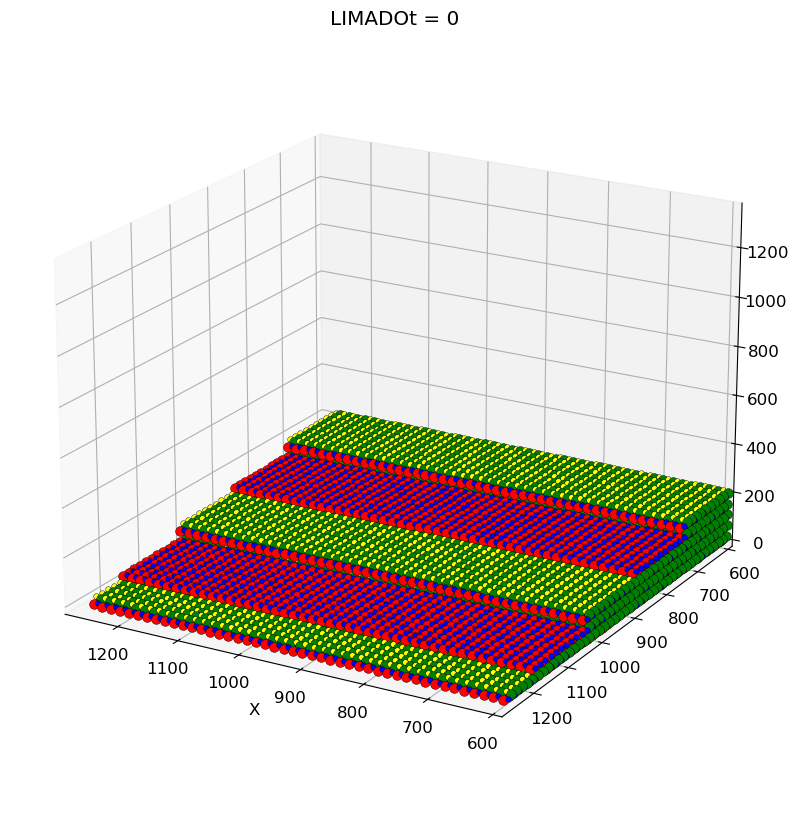

In [10]:
lx,ly = 100,100
prob_crecimiento_Ga = 0.0005# 0.0005*20
prob_crecimiento_As = 0.0001#0.000001*20
m = np.zeros((4,lx,ly), dtype=np.int32)

for x in range(lx):
    for y in range(ly):
        k = max(0,int(y/10))
        for i in range(2):
            m[i][x][ly - y - 1] = k
            if int(y/10)%2 == 0:
                m[i+2][x][ly - y - 1] = max(0,k - 1)
            else:
                m[i+2][x][ly - y - 1] = k
window = {
    "xi": 40,
    "yi": 40,
    "l": 45  
}
path = "ZincBlenda_STEPFLOW_X"
title = f"Cristal de GaAs limado hacia X (ultima capa en As)\nProbabilidades de deposicion: Ga = {prob_crecimiento_Ga}, As = {prob_crecimiento_As}\n"
donaciones = np.zeros((4, lx, ly), dtype=np.int32)
crecimientos = np.zeros((4, lx, ly), dtype=np.int32)

card = np.zeros((4,lx,ly,4,2), dtype=np.int32)
f = np.zeros((4,lx,ly,4,4), dtype=np.int32) #PRIMEROS VECINOS
s = np.zeros((4,lx,ly,4,3,4), dtype=np.int32) #SEGUNDOS VECINOS
n_actual = np.zeros((4,lx,ly), dtype=np.int32)
n_next = np.zeros((4,lx,ly), dtype=np.int32)


behind = np.zeros((4,lx,ly), dtype=np.int32)
after = np.zeros((4,lx,ly), dtype=np.int32)
donadores = np.zeros((4,lx,ly,2), dtype=np.int32)
receptores = np.zeros((4,lx,ly,4), dtype=np.bool_)
T_i = np.zeros((4,lx,ly,4), dtype=np.float64)

#print(m[0][39][40:85],m[2][84][40:85])
plot_scatter_cristal(m,0,ly,lx,window,path,"LIMADO",0)

In [ ]:
#rheed,m_out = run_simulation(m,card,f,s,behind,after,n_actual,n_next,donadores,receptores,T_i,prob_crecimiento_Ga,prob_crecimiento_As,lx,ly,window,donaciones,crecimientos,path,title)

In [ ]:
lx,ly = 100,100
prob_crecimiento_Ga = 0.0005# 0.0005*20
prob_crecimiento_As = 0.00001#0.000001*20
m = np.zeros((4,lx,ly), dtype=np.int32)
for x in range(lx):
    for y in range(ly):
        m[0][x][y] = 1
##        for j in range(9):
 #           if x   > 10*(j+1):
 #               for i in range(4):
 #                  m[i][x][y] = j + 1
                #m[3][x][y] -= 1 
window = {
    "xi": 0,
    "yi": 0,
    "l": 50,   
}
path = "ZINCBLENDA_UNIFORME_Ga"
title = f"Cristal de GaAs con sustrato Ideal de Ga \nProbabilidades de deposicion: Ga = {prob_crecimiento_Ga}, As = {prob_crecimiento_As}"
donaciones = np.zeros((4, lx, ly), dtype=np.int32)
crecimientos = np.zeros((4, lx, ly), dtype=np.int32)

card = np.zeros((4,lx,ly,4,2), dtype=np.int32)
f = np.zeros((4,lx,ly,4,4), dtype=np.int32) #PRIMEROS VECINOS
s = np.zeros((4,lx,ly,4,3,4), dtype=np.int32) #SEGUNDOS VECINOS
n_actual = np.zeros((4,lx,ly), dtype=np.int32)
n_next = np.zeros((4,lx,ly), dtype=np.int32)


behind = np.zeros((4,lx,ly), dtype=np.int32)
after = np.zeros((4,lx,ly), dtype=np.int32)
donadores = np.zeros((4,lx,ly,2), dtype=np.int32)
receptores = np.zeros((4,lx,ly,4), dtype=np.bool_)
T_i = np.zeros((4,lx,ly,4), dtype=np.float64)
#rheed,m_out = run_simulation(m,card,f,s,behind,after,n_actual,n_next,donadores,receptores,T_i,prob_crecimiento_Ga,prob_crecimiento_As,lx,ly,window,donaciones,crecimientos,path,title)

In [ ]:
rheed.to_csv(f'ZINCBLENDA_STEPFLOW_Y/RHEED_Y_positivo.csv',index=False)

In [14]:
import pandas as pd
rheed = pd.read_csv('ZINCBLENDA_Uniforme5.csv')
#for col in rheed.columns:
    #if col != 't':
        #rheed[col] = rheed[col]*2 - 1

In [11]:
rheed

,t,0,1,2,3,4,5,6,7,8,...,350,351,352,353,354,355,356,357,358,359
0,0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.997266,0.997780,0.998242,0.998652,0.999008,0.999310,0.999558,0.999751,0.999889,0.999972
1,1000,0.952106,0.952114,0.952138,0.952178,0.952234,0.952305,0.952392,0.952495,0.952614,...,0.950411,0.950730,0.951017,0.951271,0.951491,0.951679,0.951832,0.951952,0.952038,0.952089
2,2000,0.920845,0.920857,0.920896,0.920960,0.921049,0.921163,0.921303,0.921468,0.921658,...,0.919846,0.920034,0.920203,0.920353,0.920483,0.920593,0.920683,0.920754,0.920804,0.920834
3,3000,0.906261,0.906275,0.906314,0.906380,0.906473,0.906591,0.906736,0.906906,0.907103,...,0.905402,0.905564,0.905709,0.905838,0.905950,0.906045,0.906123,0.906183,0.906227,0.906253
4,4000,0.901968,0.901980,0.902018,0.902081,0.902169,0.902281,0.902419,0.902581,0.902768,...,0.901067,0.901237,0.901389,0.901524,0.901641,0.901741,0.901822,0.901886,0.901931,0.901959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,145000,0.898530,0.898535,0.898550,0.898575,0.898611,0.898657,0.898712,0.898778,0.898854,...,0.898500,0.898506,0.898511,0.898515,0.898519,0.898522,0.898525,0.898527,0.898528,0.898529
146,146000,0.897715,0.897720,0.897736,0.897762,0.897798,0.897845,0.897902,0.897969,0.898046,...,0.897700,0.897703,0.897705,0.897708,0.897710,0.897711,0.897713,0.897714,0.897714,0.897715
147,147000,0.897878,0.897883,0.897898,0.897922,0.897957,0.898001,0.898056,0.898120,0.898193,...,0.897873,0.897874,0.897875,0.897875,0.897876,0.897877,0.897877,0.897877,0.897878,0.897878
148,148000,0.897796,0.897801,0.897815,0.897837,0.897869,0.897910,0.897960,0.898019,0.898087,...,0.897737,0.897749,0.897758,0.897767,0.897775,0.897781,0.897787,0.897791,0.897794,0.897796


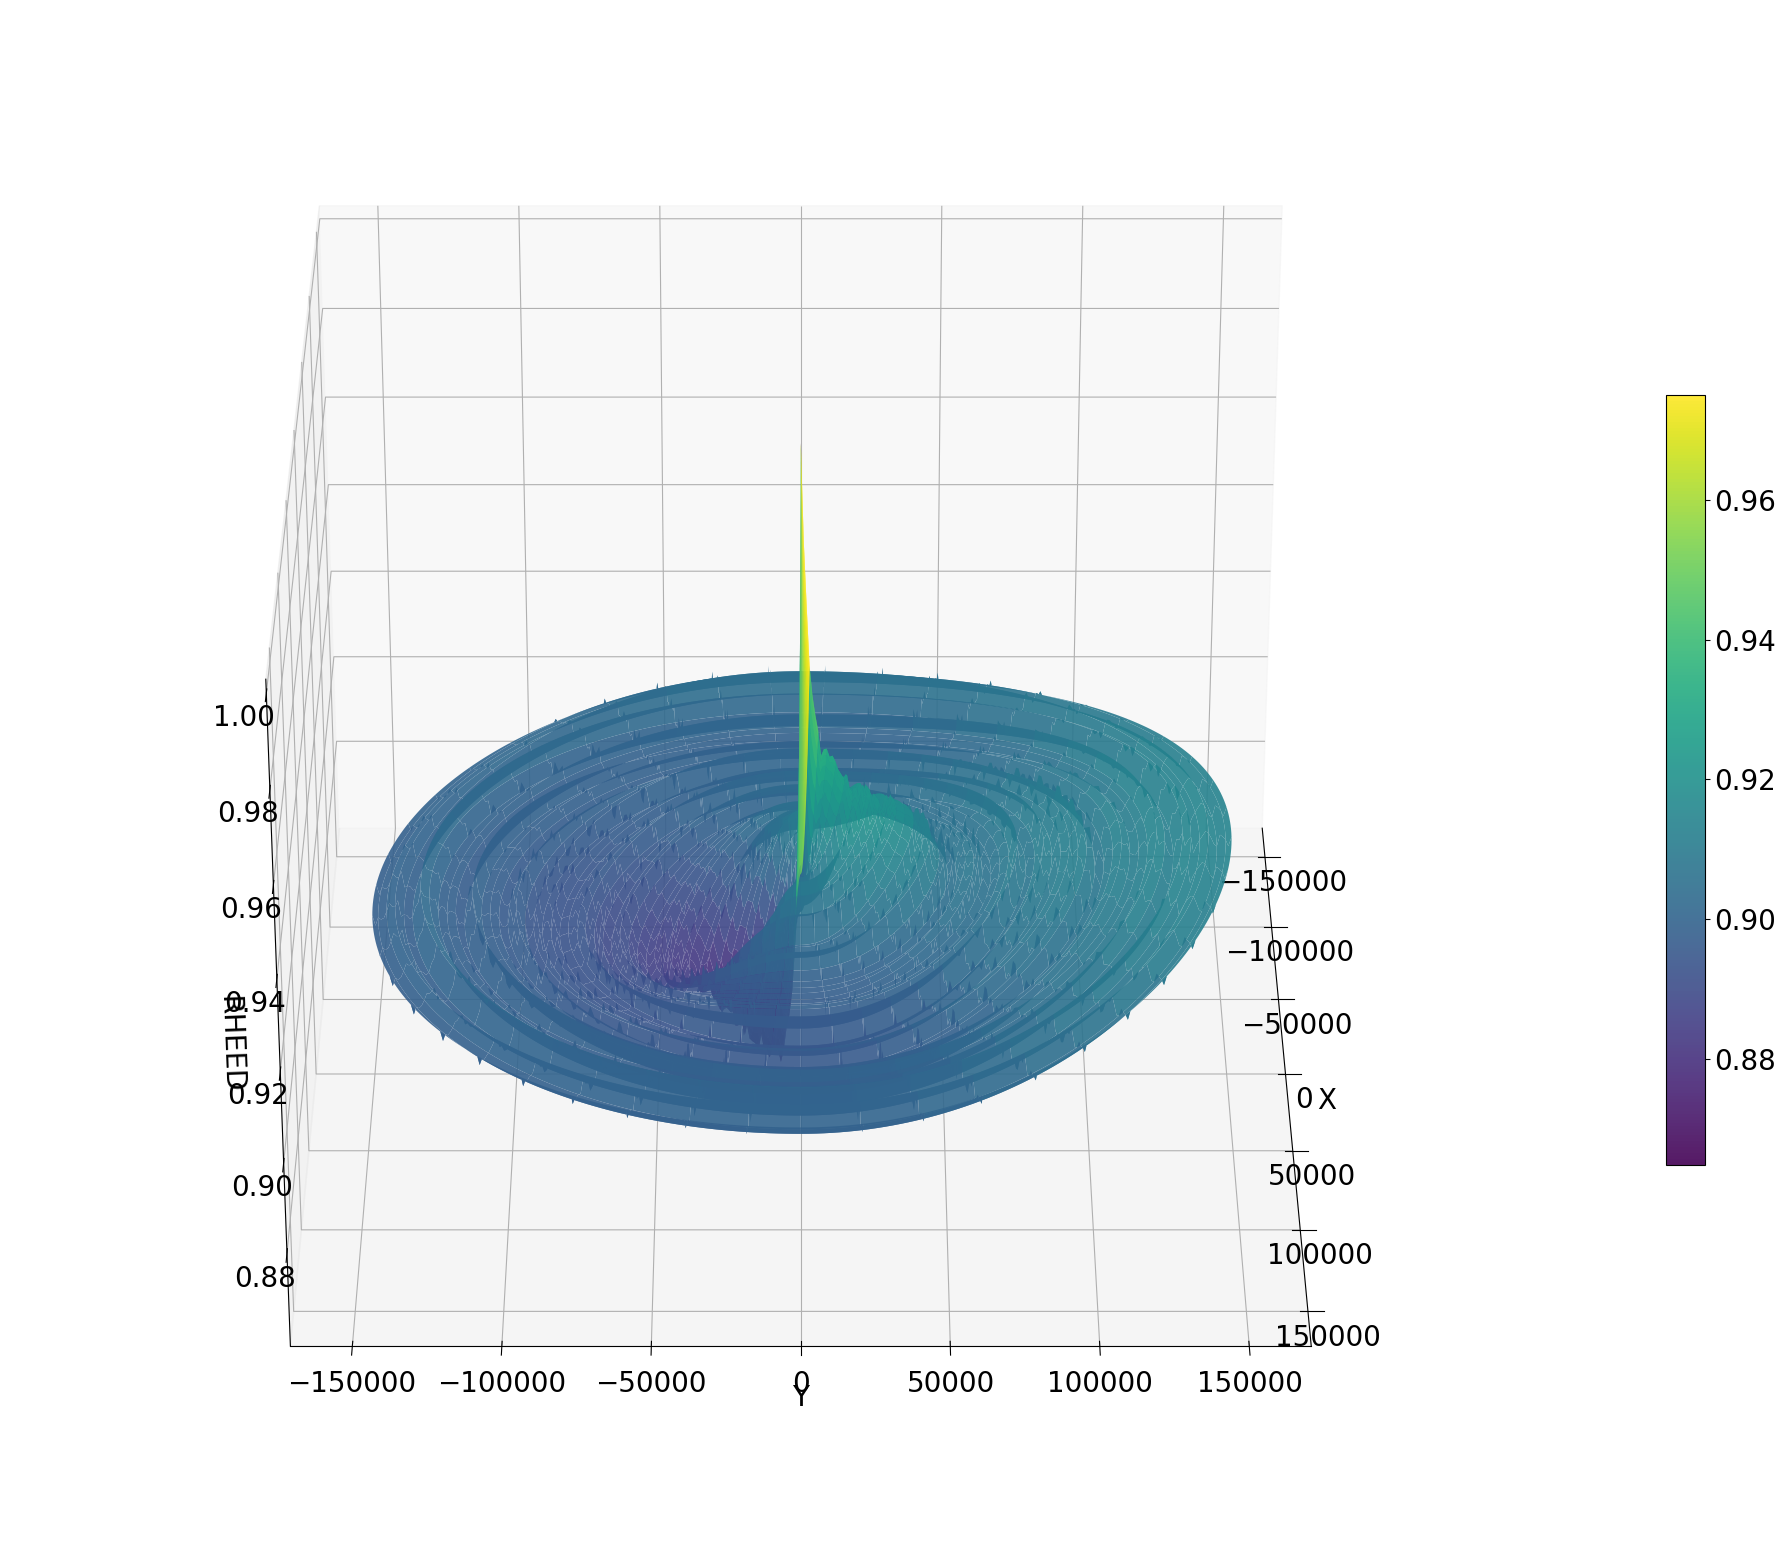

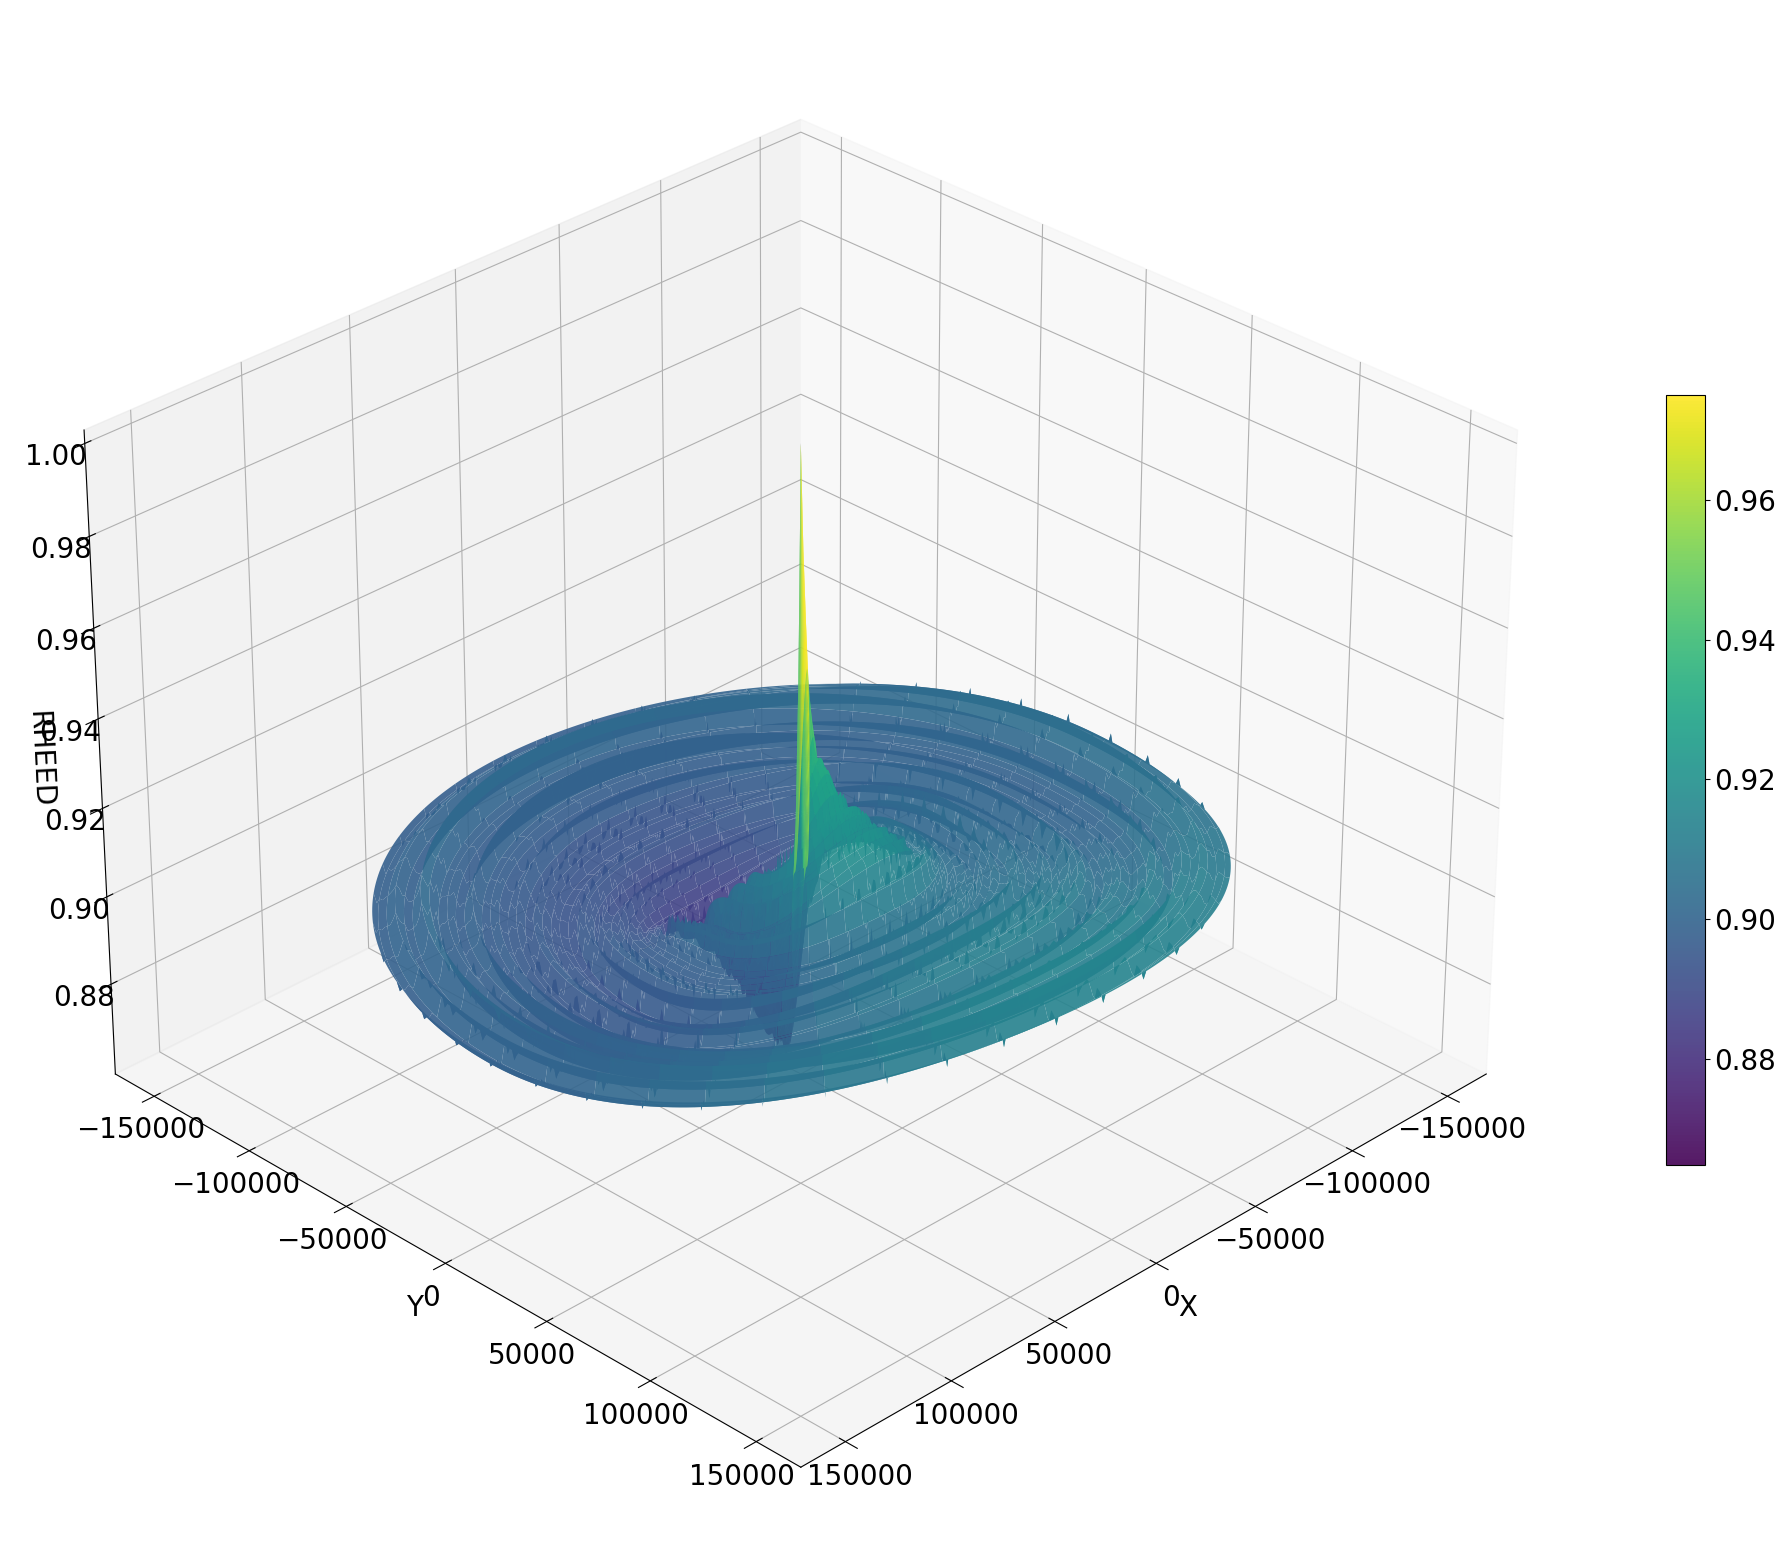

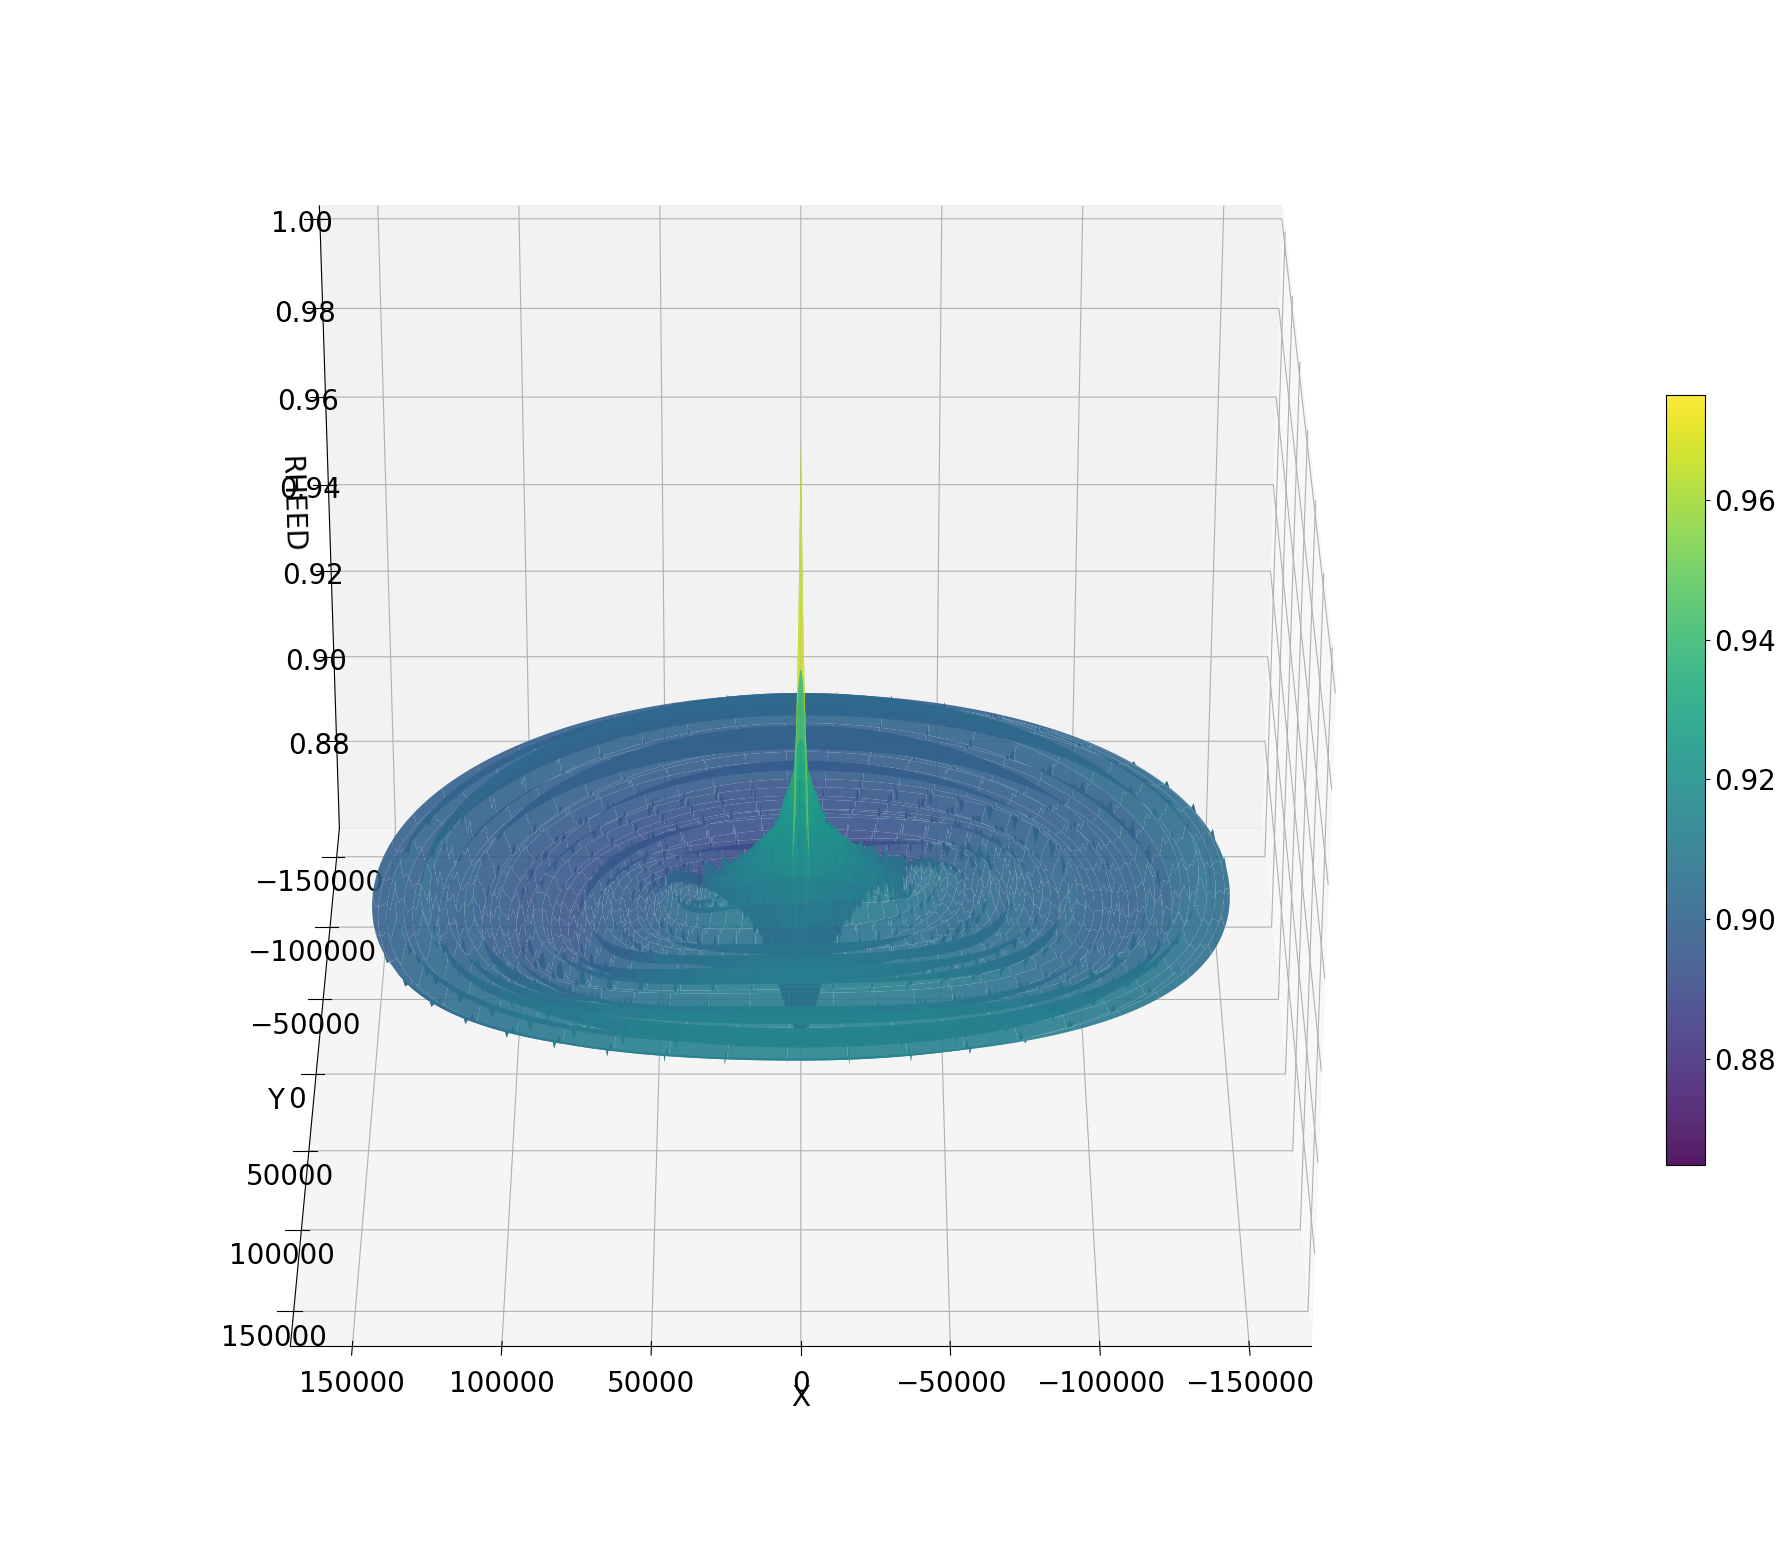

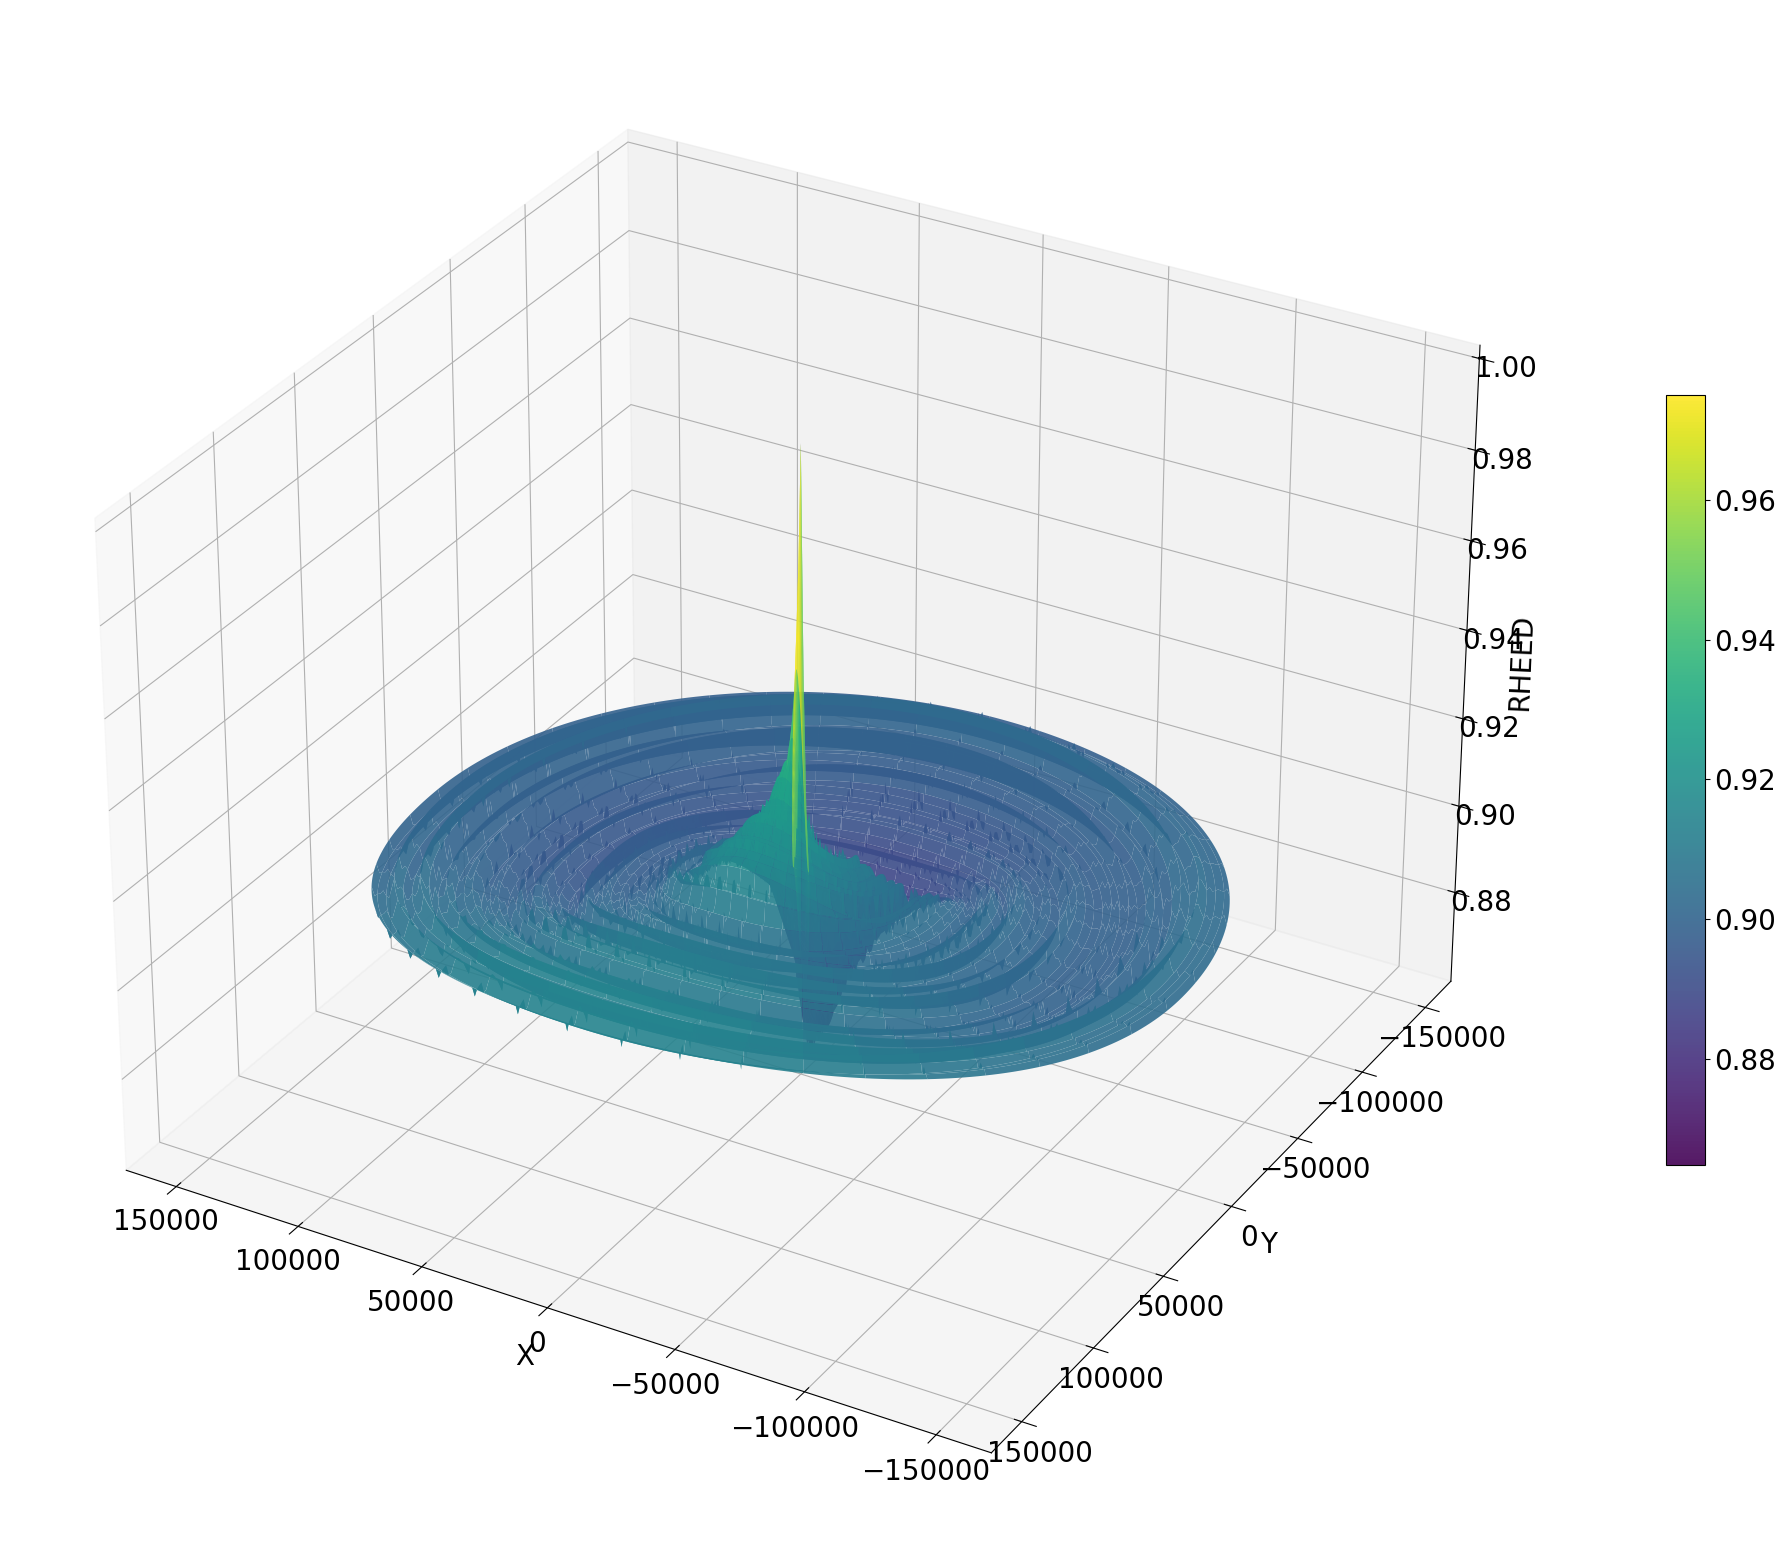

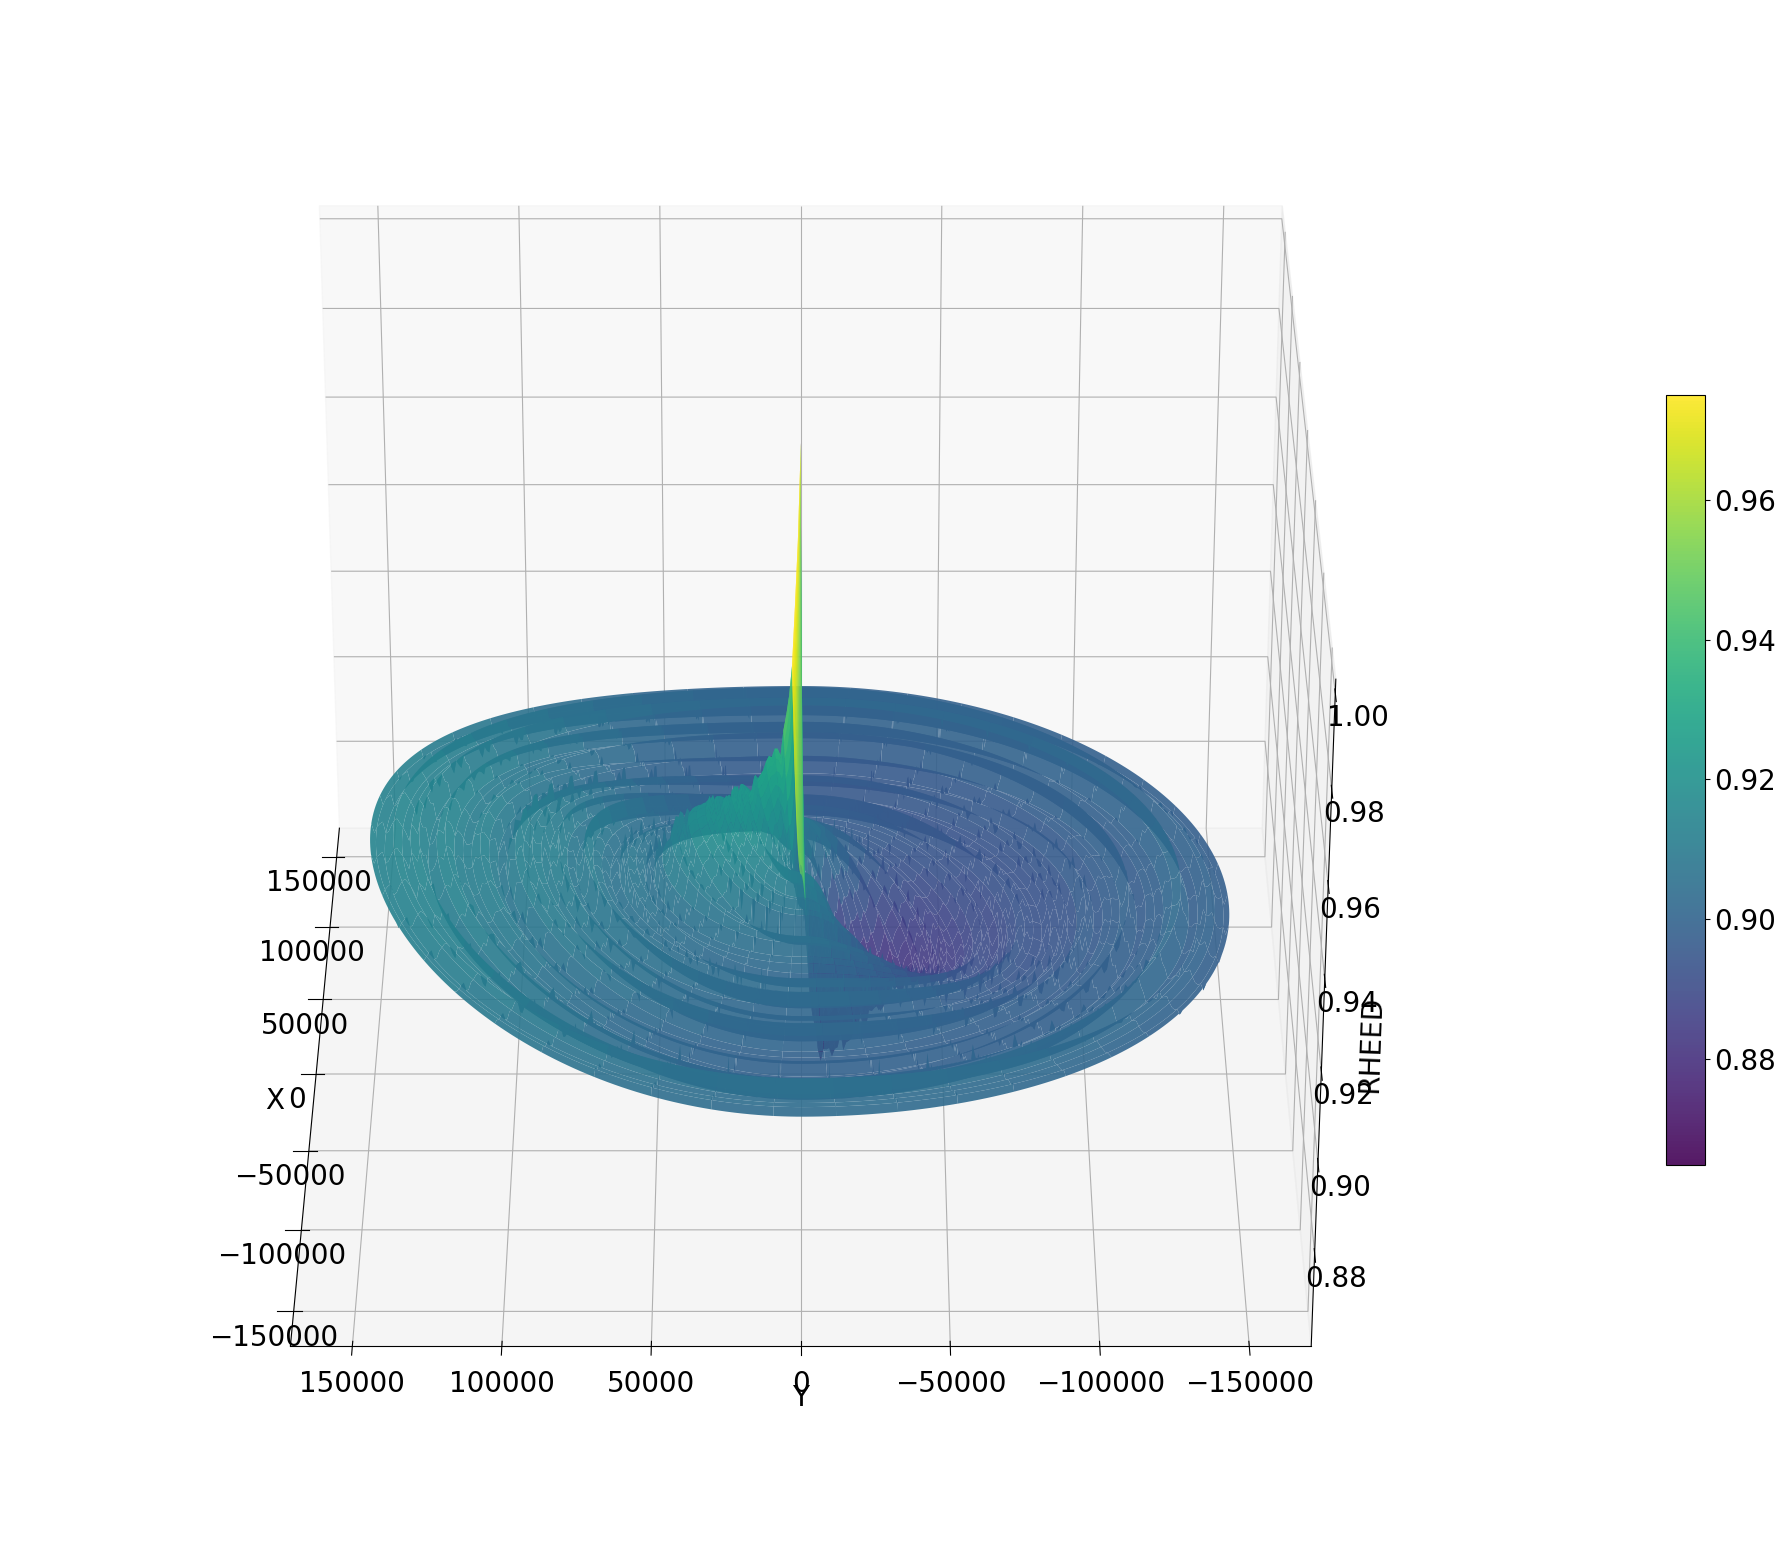

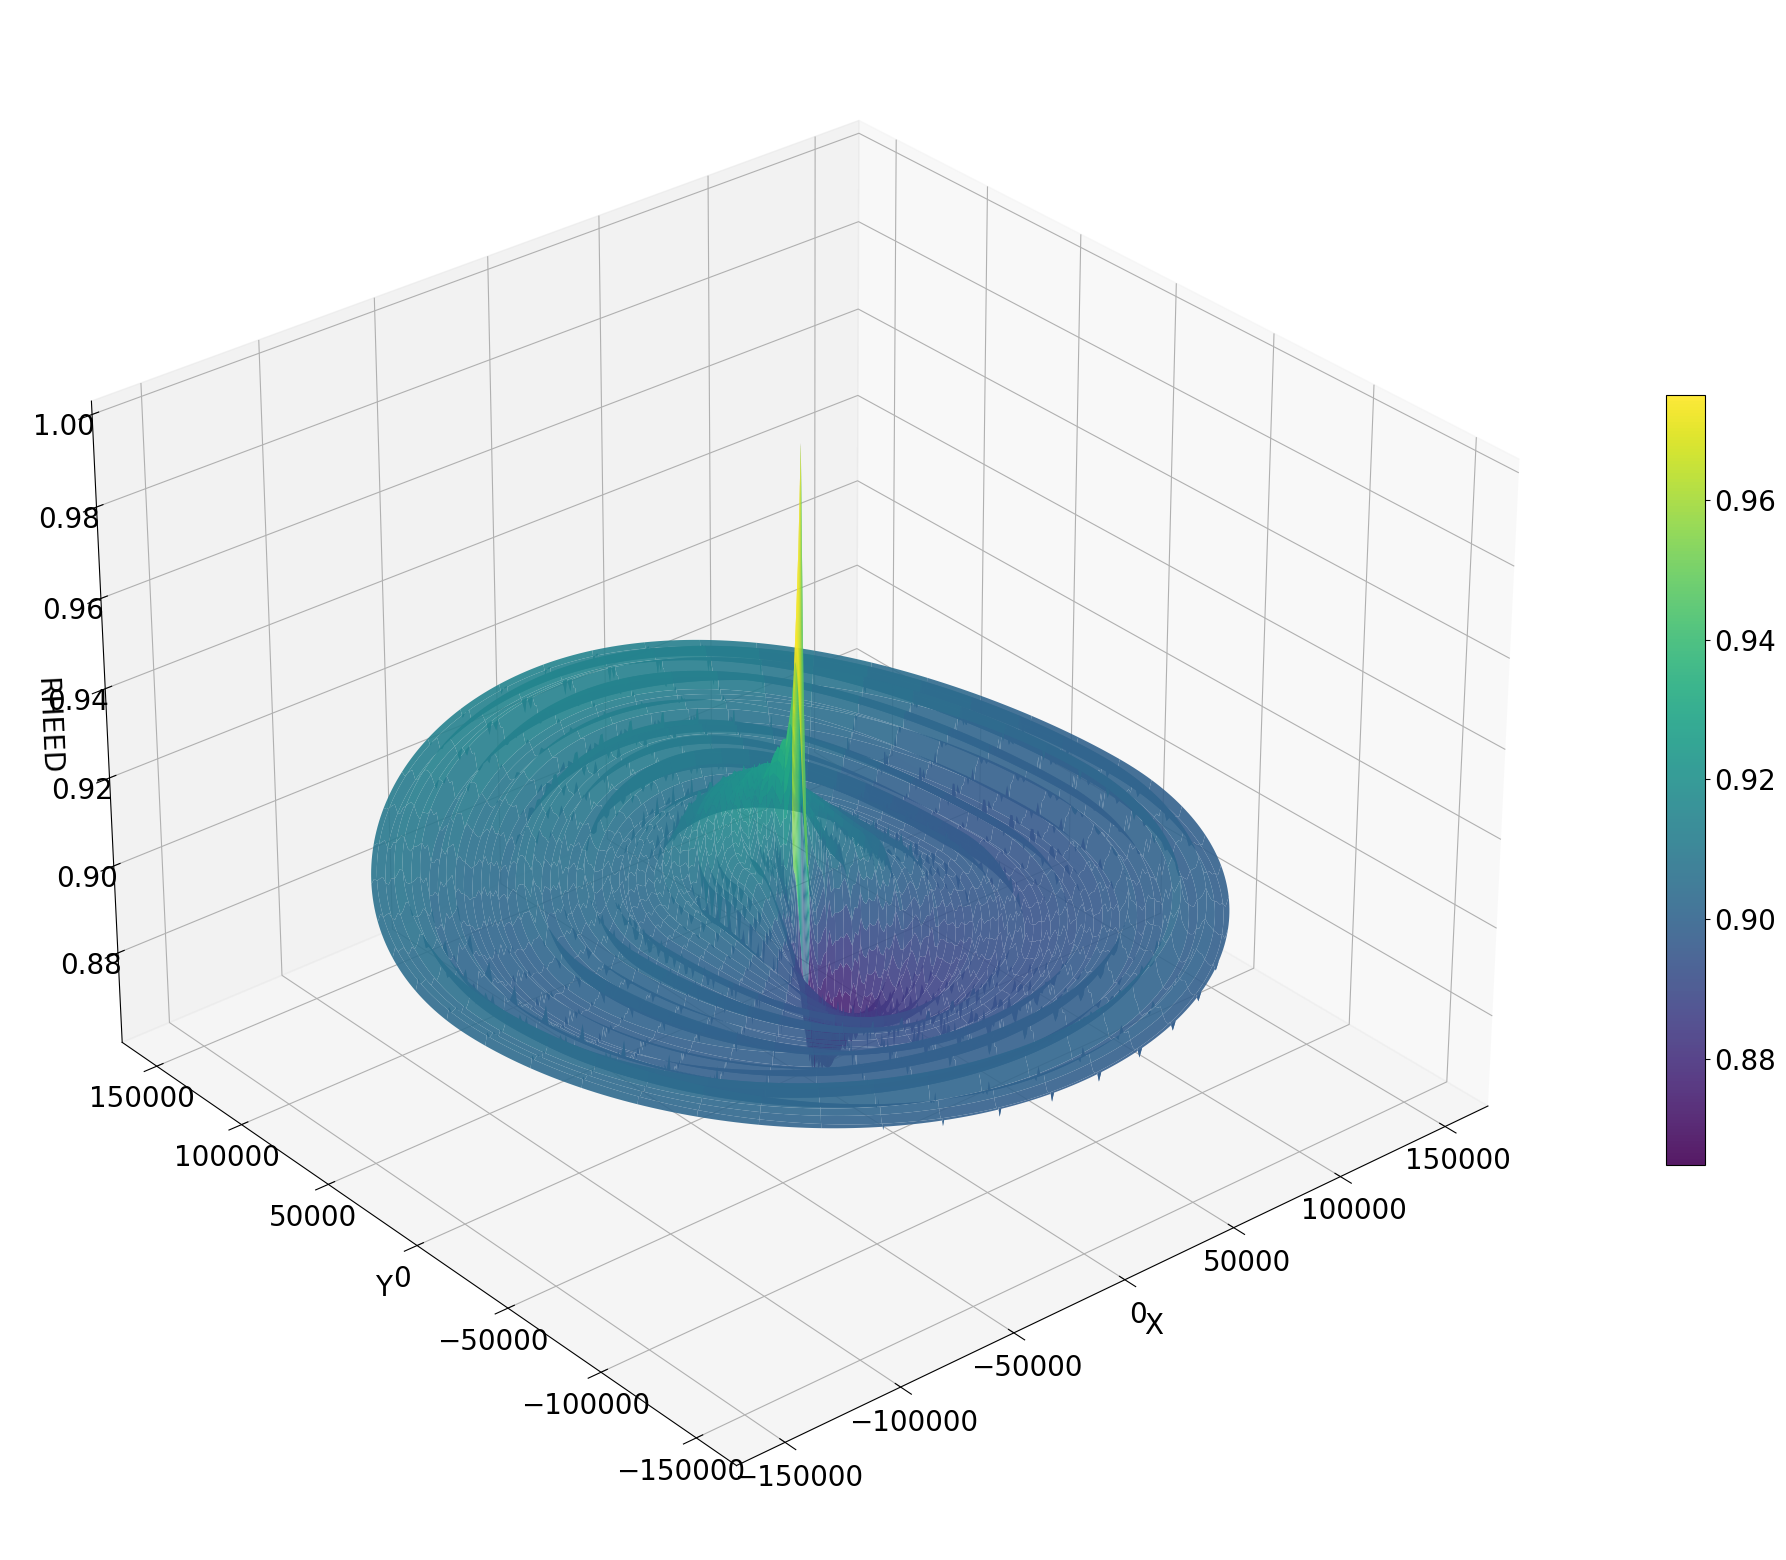

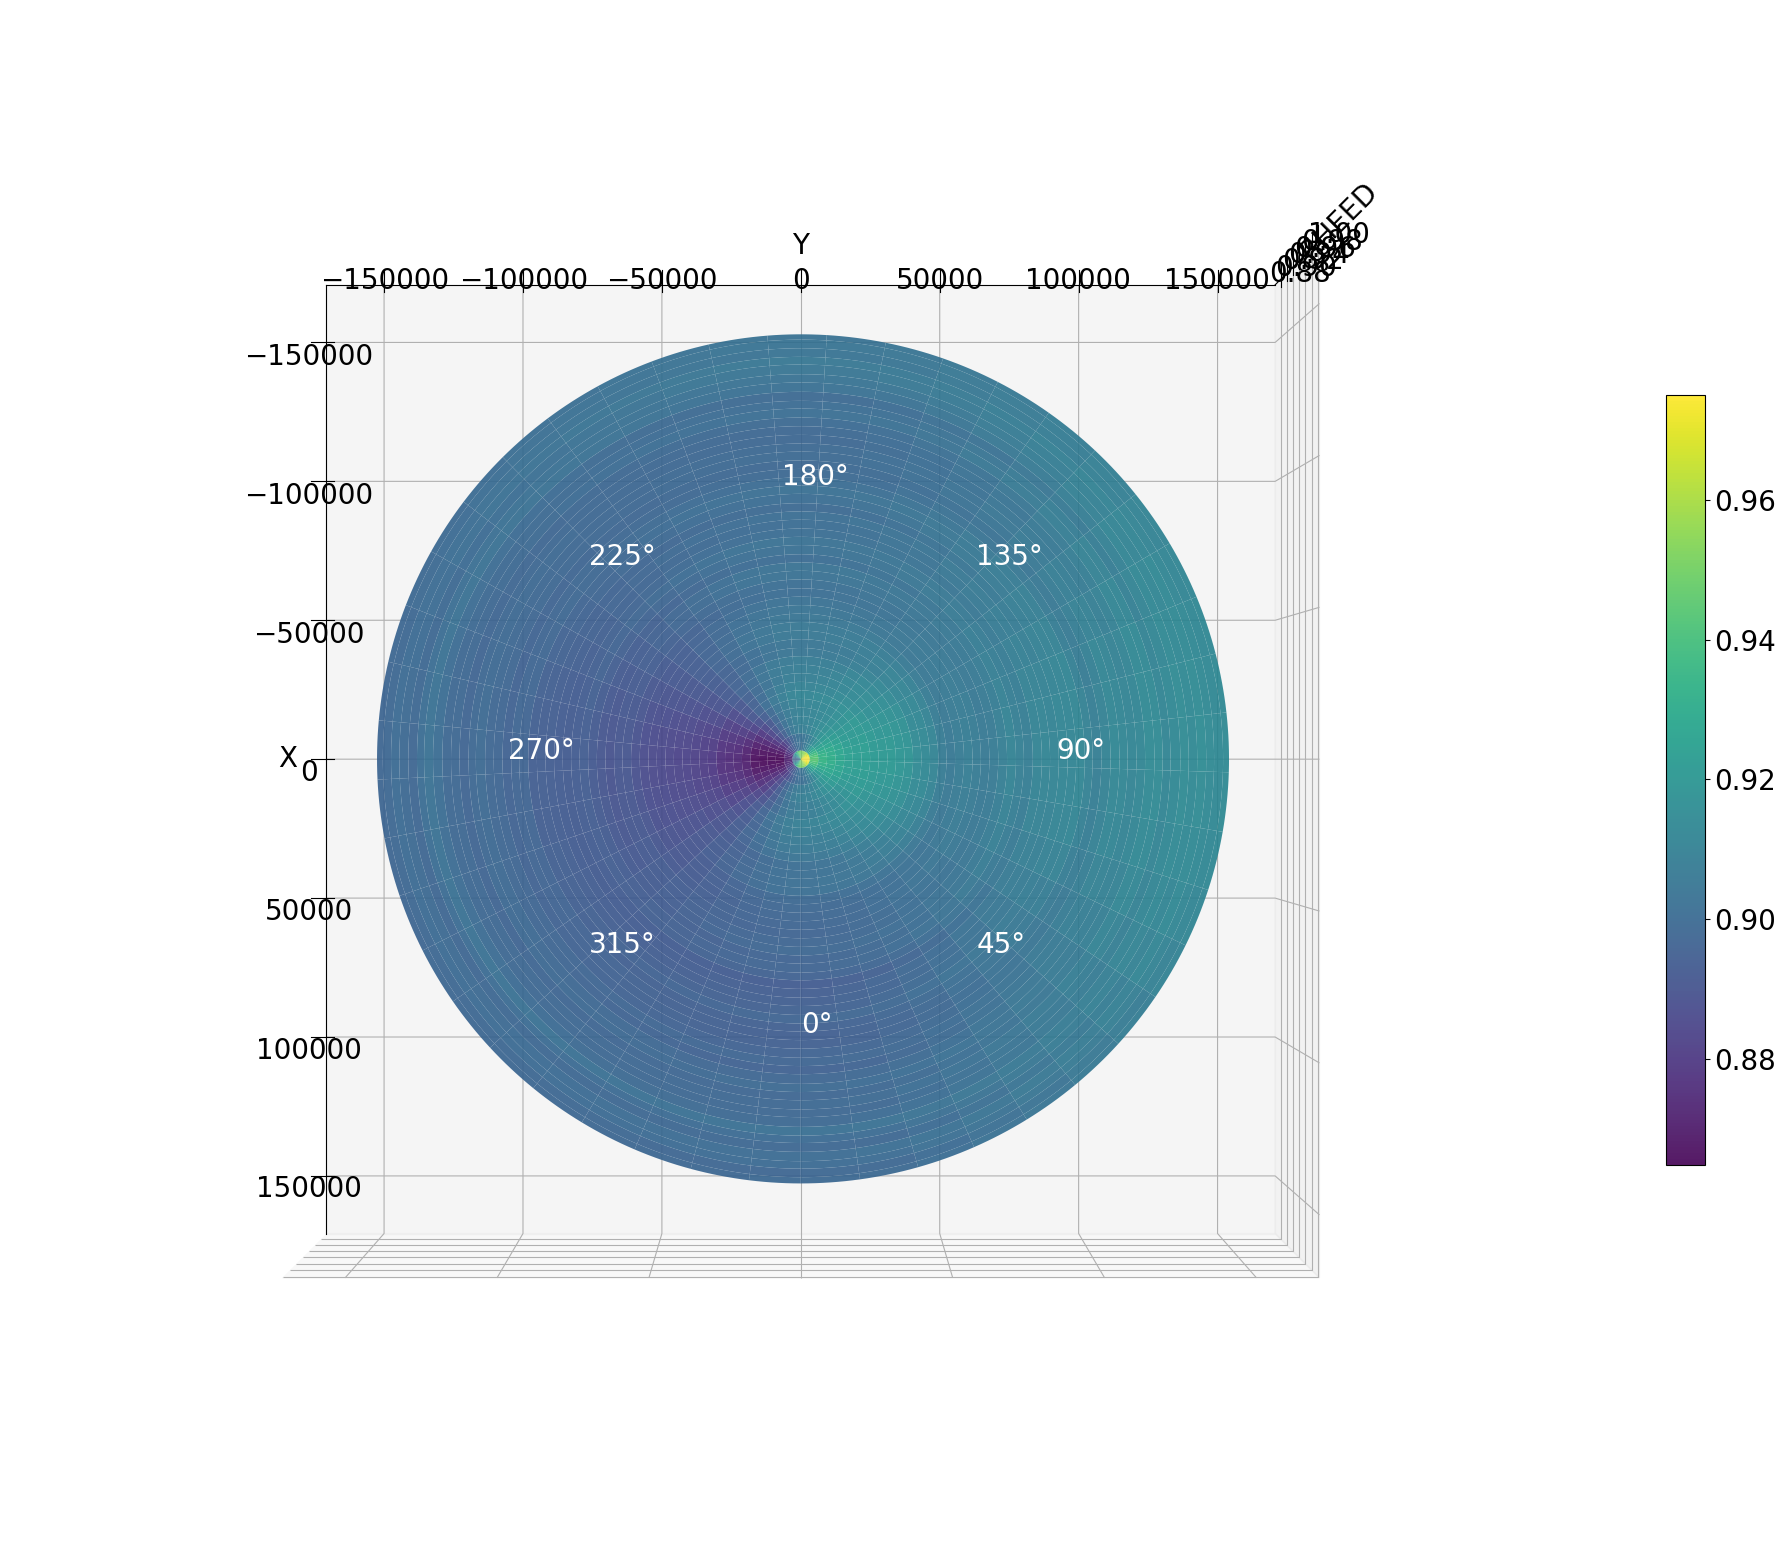

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Ajustar el tamaño de la fuente globalmente
plt.rcParams.update({'font.size': 20})  # Aumenta el tamaño de la fuente en 4 puntos

# Función para transformar coordenadas polares a cartesianas y graficar superficie
def polar_to_surface_plot(df, elev, azim):
    """
    Transforma un DataFrame con coordenadas polares en una gráfica de superficie 3D.

    Args:
        df: DataFrame con columna 't' (radio) y columnas de ángulos en radianes.
    """
    # Extraer la columna t como R
    R = df['t'].values

    # Extraer las columnas de ángulos (suponemos que son las demás columnas)
    angles = df.iloc[:, 1:].values

    # Crear una grilla de coordenadas polares
    theta = np.linspace(0, 2 * np.pi, angles.shape[1])  # Dividir uniformemente los ángulos
    r, th = np.meshgrid(R, theta)

    # Calcular coordenadas cartesianas
    X = r * np.cos(th)
    Y = r * np.sin(th)

    # Usar los valores de altura directamente desde el DataFrame
    Z = np.array(angles.T)  # Transponer para coincidir con la grilla

    # Crear la figura y el eje 3D
    fig = plt.figure(figsize=(30, 20))
    ax = fig.add_subplot(111, projection='3d')

    # Crear la superficie
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    
    # Dibujar las líneas de ángulos notables
    notable_angles = np.radians([0, 45, 90,  135,  180,  225,  270,315])
    for angle in notable_angles:
        #ax.plot([0, R.max() * np.cos(angle)], [0, R.max() * np.sin(angle)], [0, 0], 'w--')
        if angle == 0:
            ax.text(R.max() * np.cos(angle), R.max() * np.sin(angle) , 0, f'{np.degrees(angle):.0f}°', color='w')
        else:    
            ax.text(R.max() * np.cos(angle), R.max() * np.sin(angle) - 10000, 0, f'{np.degrees(angle):.0f}°', color='w')
        

    # Ajustar la vista de la cámara
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('RHEED')
   # ax.set_zlim(0.975,1)
    # Agregar barra de color
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=20)

    #plt.title(f"Plano 3D de intensidad RHEED del crecimiento de GaAs limado hacia +X (Ultima capa en Ga)\nProbabilidades de deposicion: Ga = {prob_crecimiento_Ga}, As = {prob_crecimiento_As}")
    plt.show()


# Llamar a la función con diferentes ángulos de vista
polar_to_surface_plot(rheed, 30, 0)
polar_to_surface_plot(rheed, 30, 45)
polar_to_surface_plot(rheed, 30, 90)
polar_to_surface_plot(rheed, 30, 120)
polar_to_surface_plot(rheed, 30, 180)
polar_to_surface_plot(rheed, 30, 230)
polar_to_surface_plot(rheed, 90, 0)


In [44]:
rheed.iloc[:, 1:].values

array([[0.50612531, 0.50834473, 0.51069651, ..., 0.512238  , 0.51025841,
        0.50823612],
       [0.56227811, 0.56509353, 0.56754468, ..., 0.56847994, 0.56645436,
        0.56444046],
       [0.53942697, 0.54163849, 0.54396583, ..., 0.54543933, 0.54351942,
        0.54152775],
       ...,
       [0.5719286 , 0.57410507, 0.57640722, ..., 0.57782246, 0.57596012,
        0.5739941 ],
       [0.57222861, 0.57441704, 0.57673181, ..., 0.57810311, 0.57622722,
        0.57424857],
       [0.57412871, 0.57630817, 0.57860978, ..., 0.57999987, 0.57812178,
        0.57614386]])

<Figure size 2000x1000 with 0 Axes>

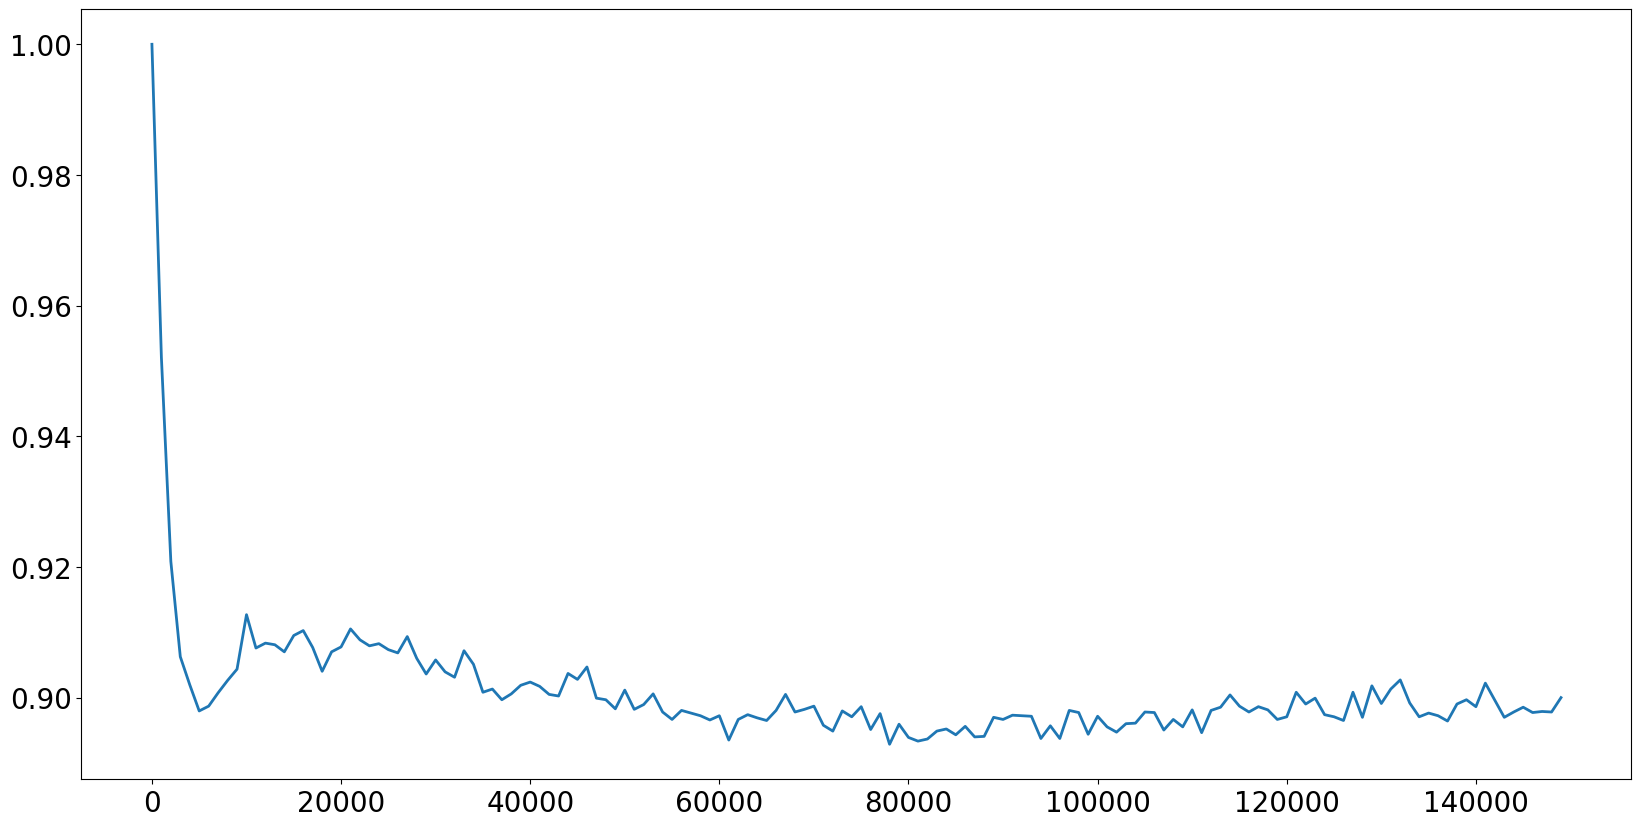

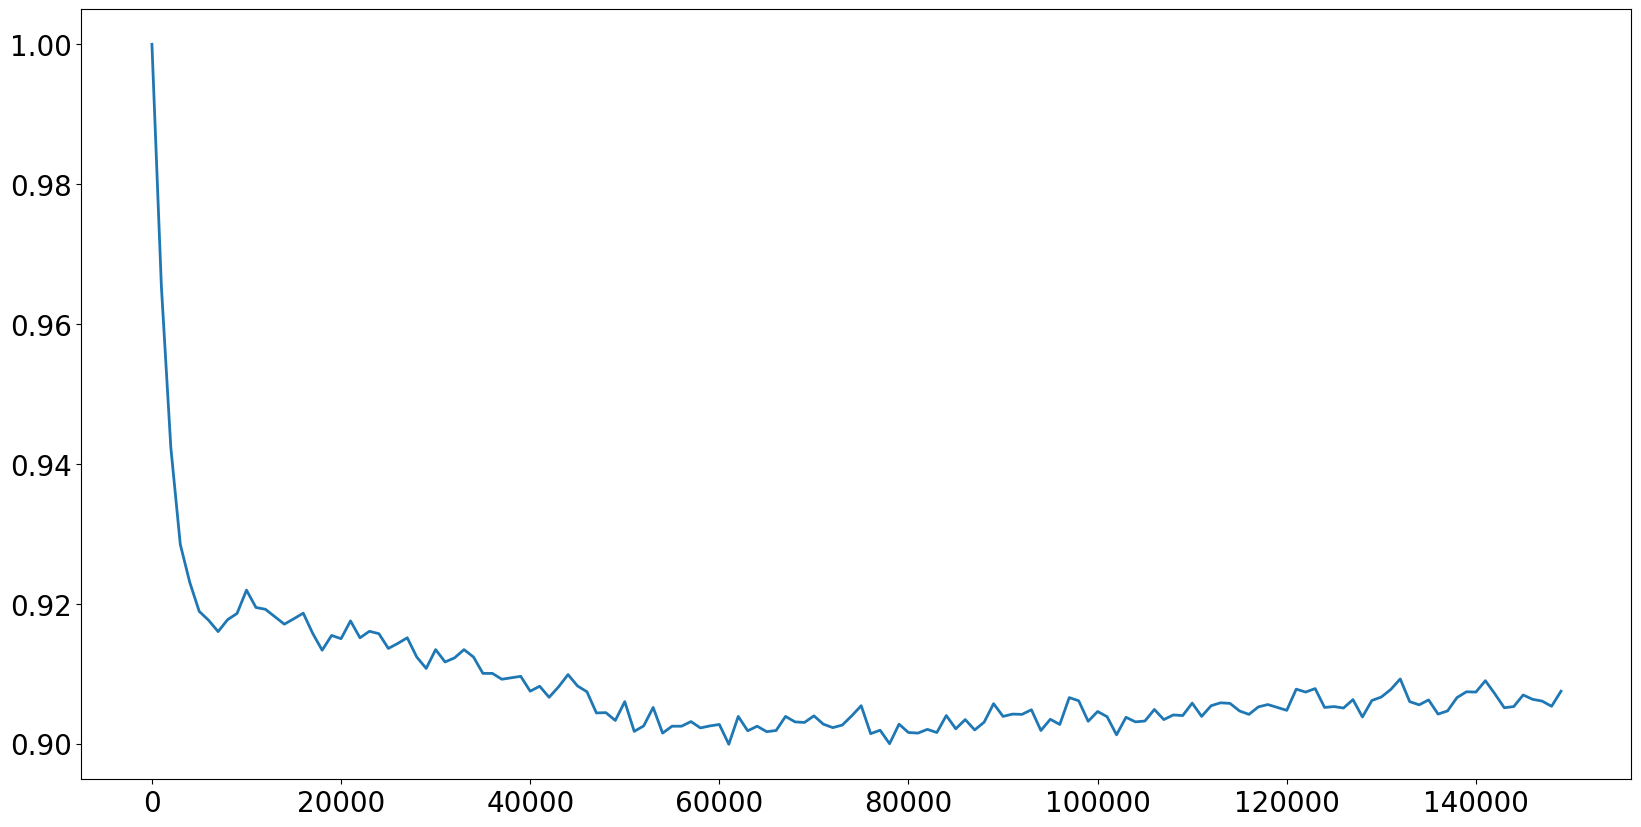

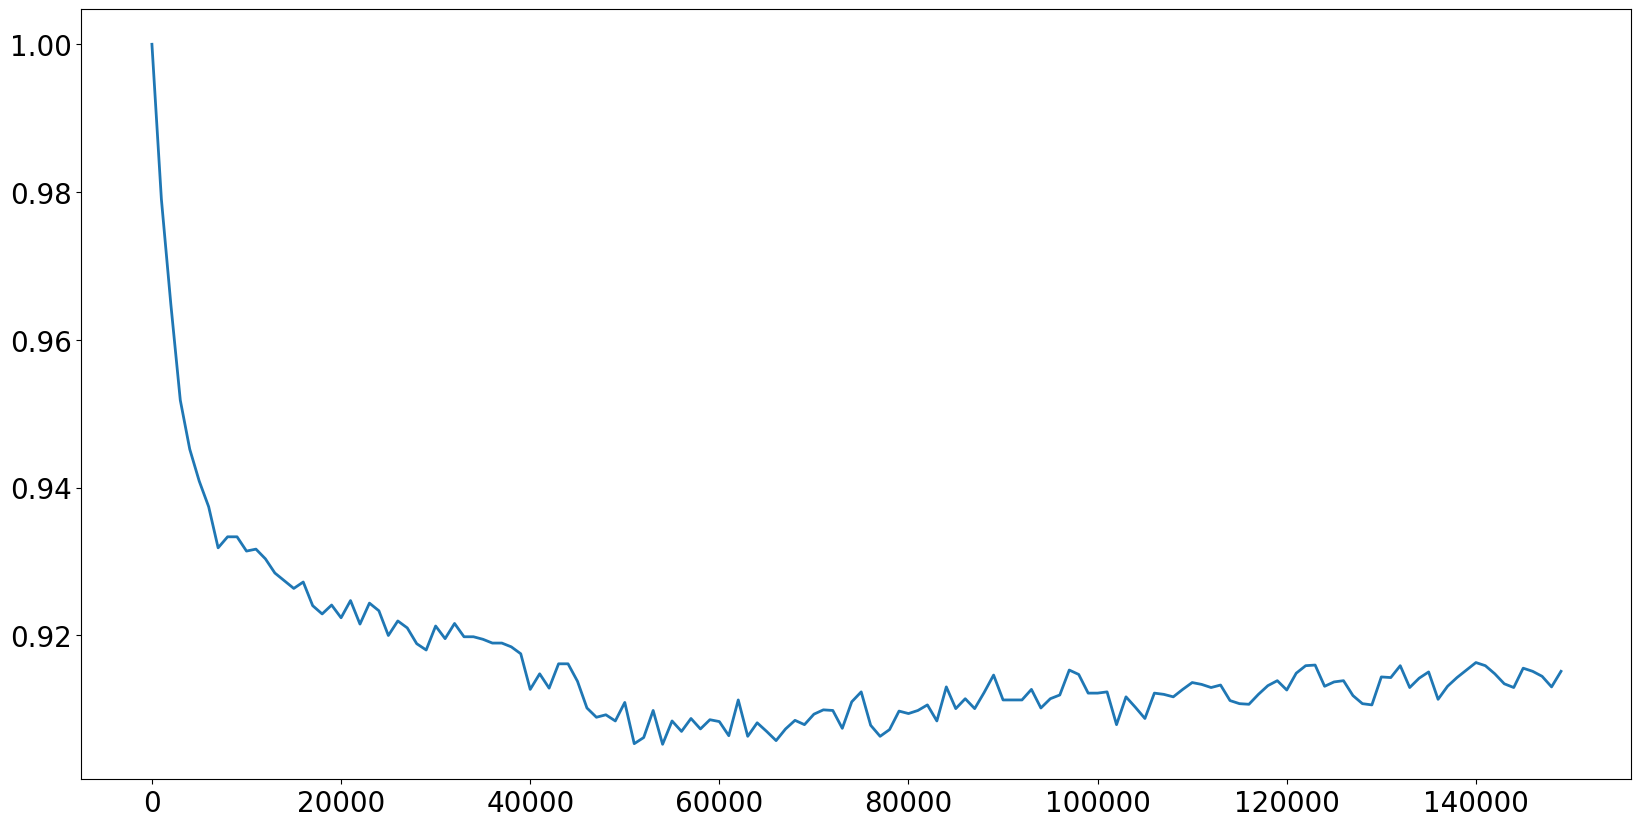

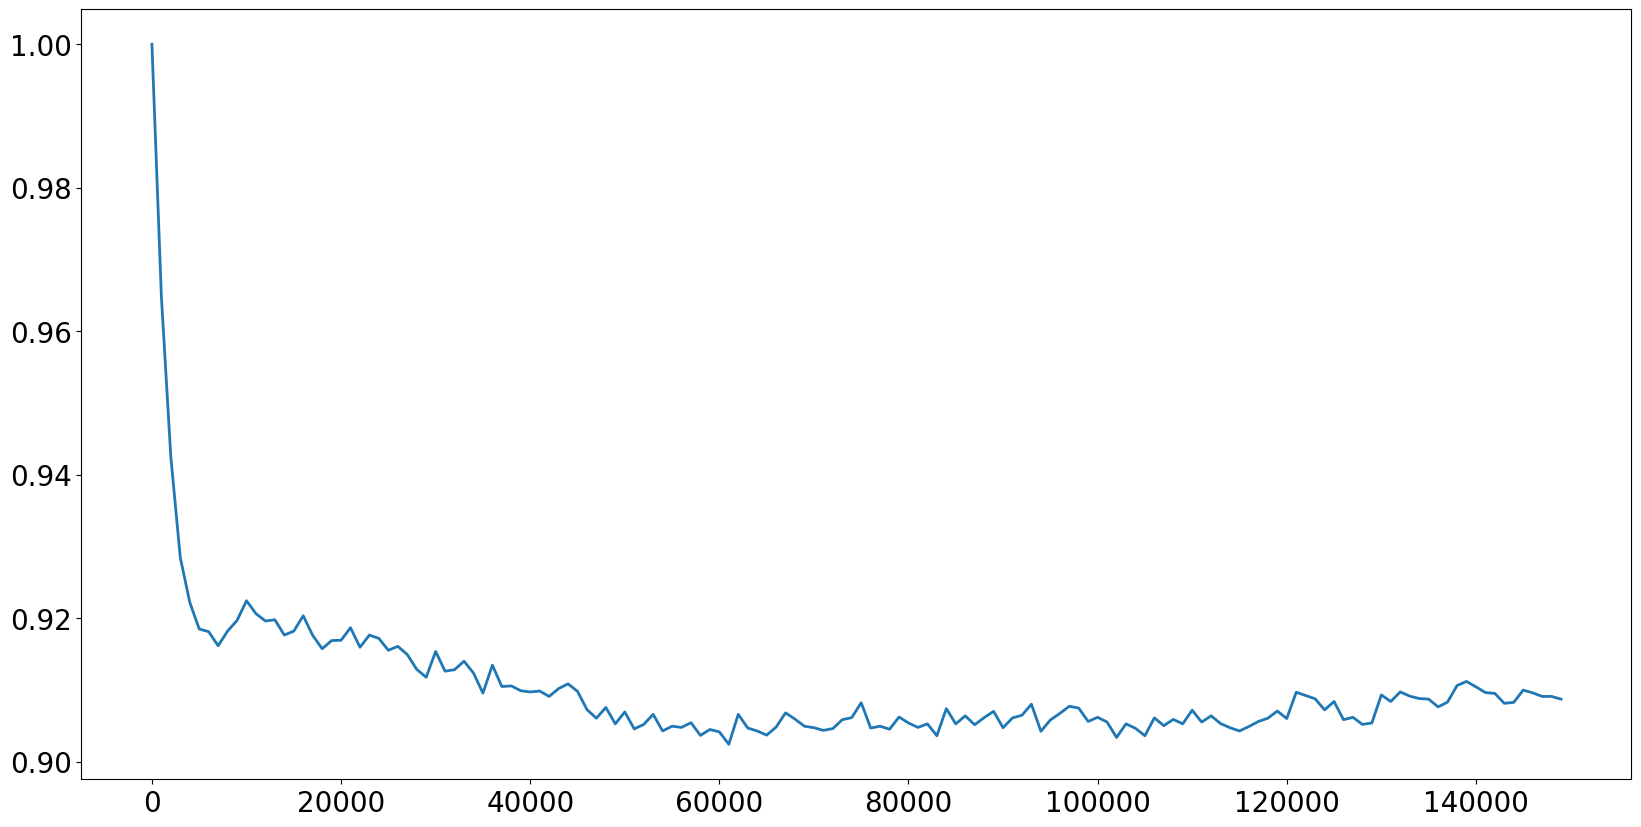

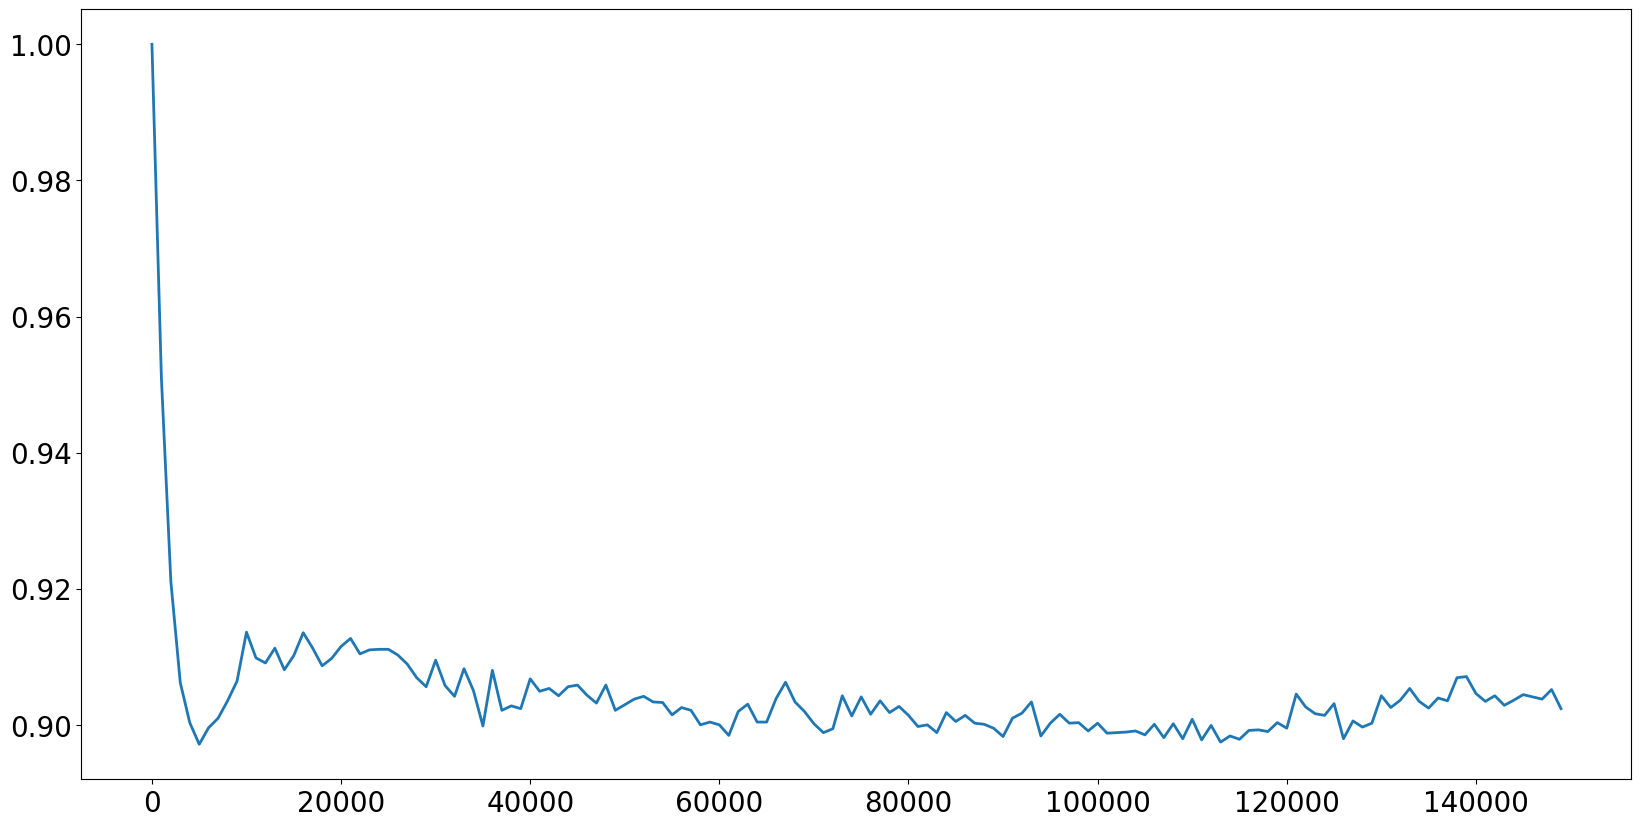

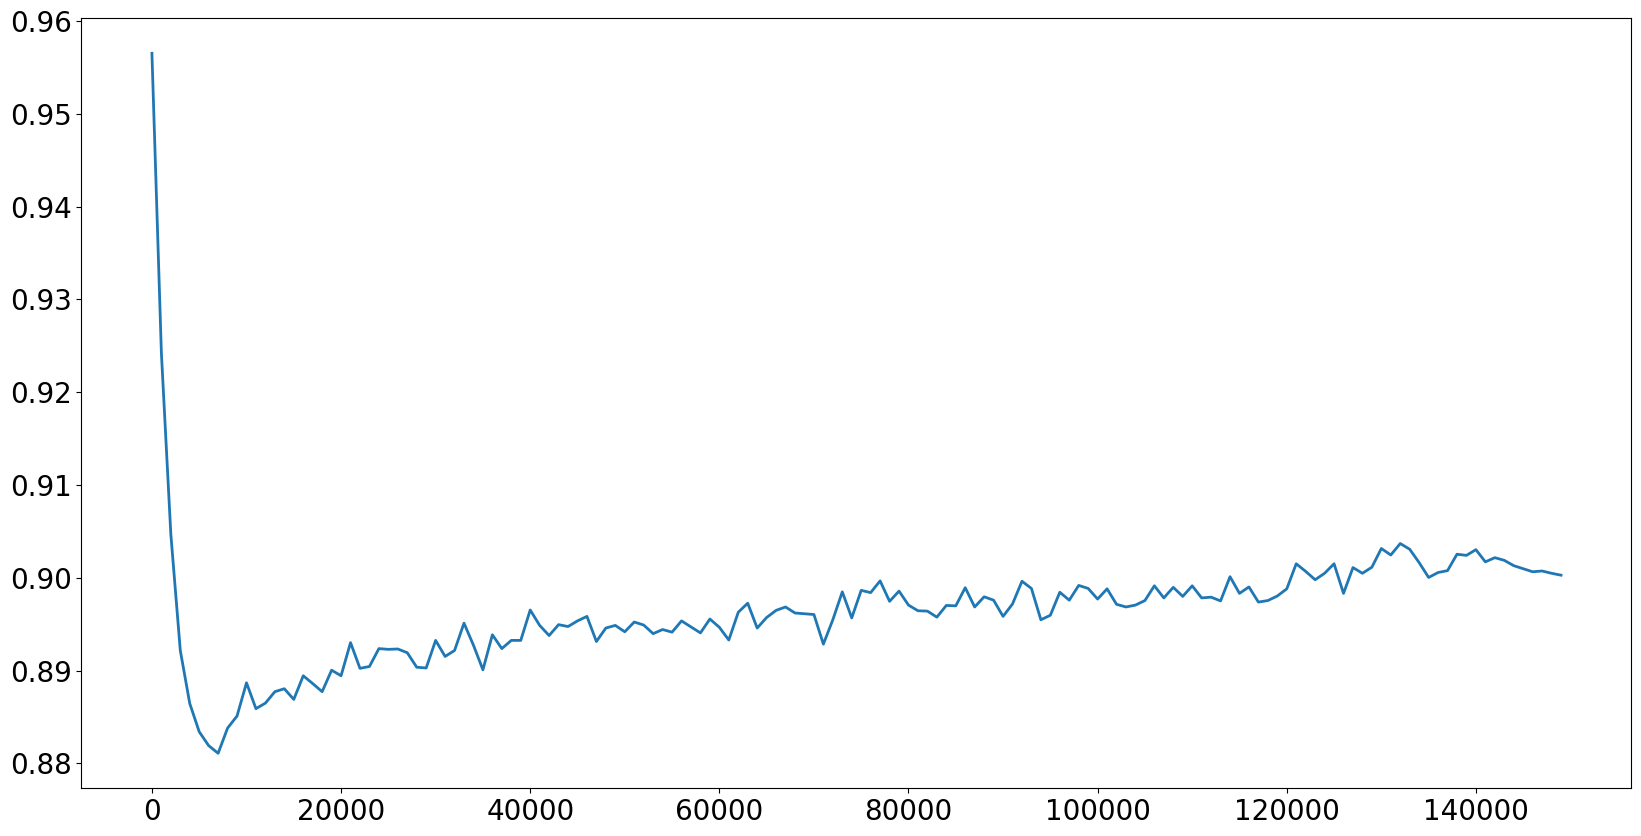

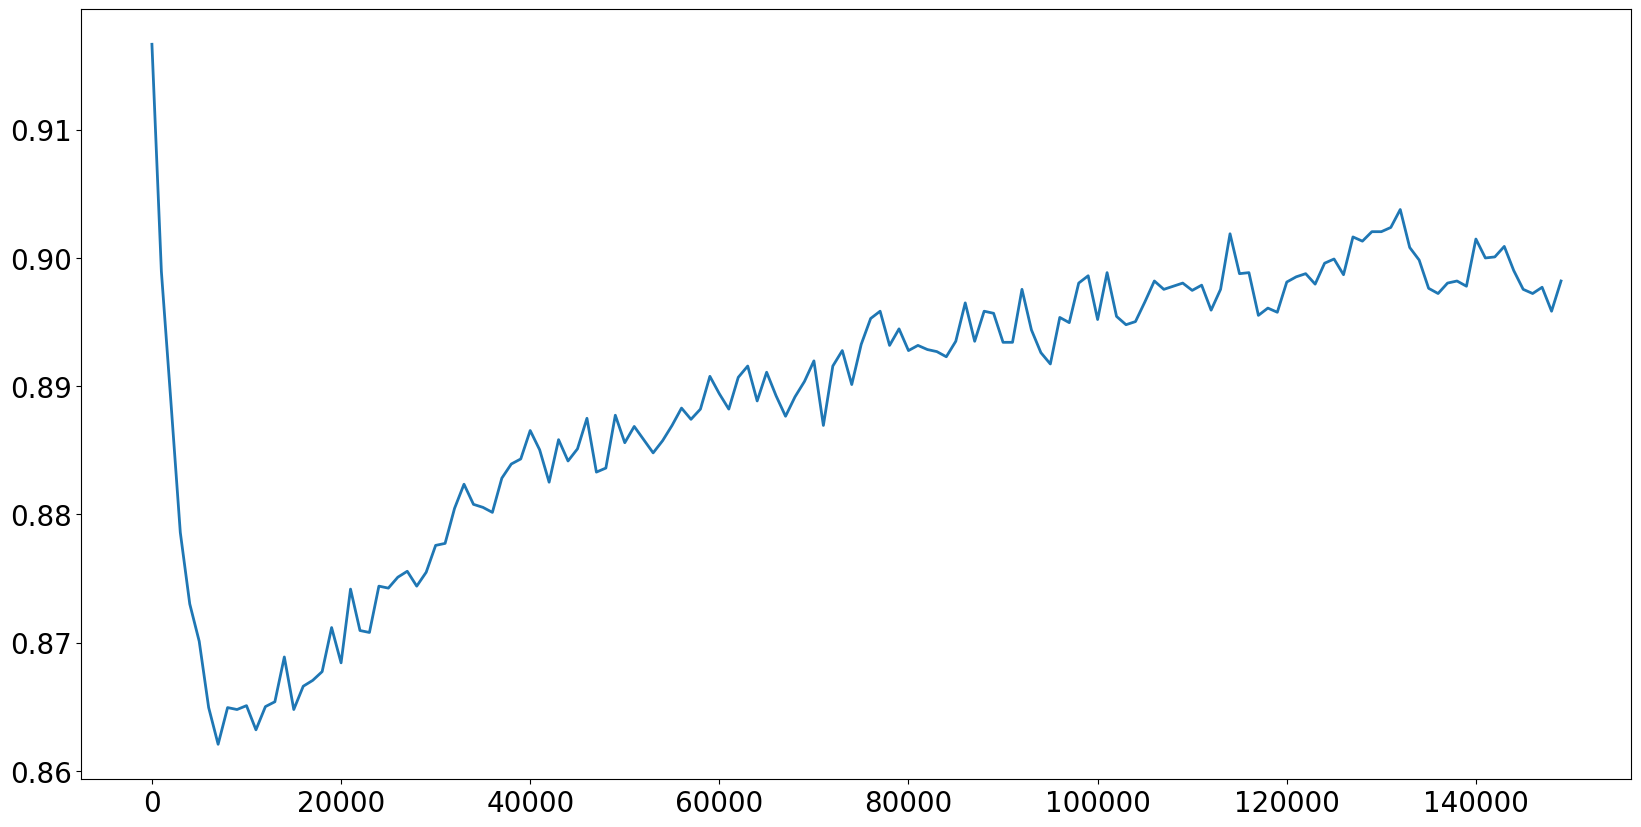

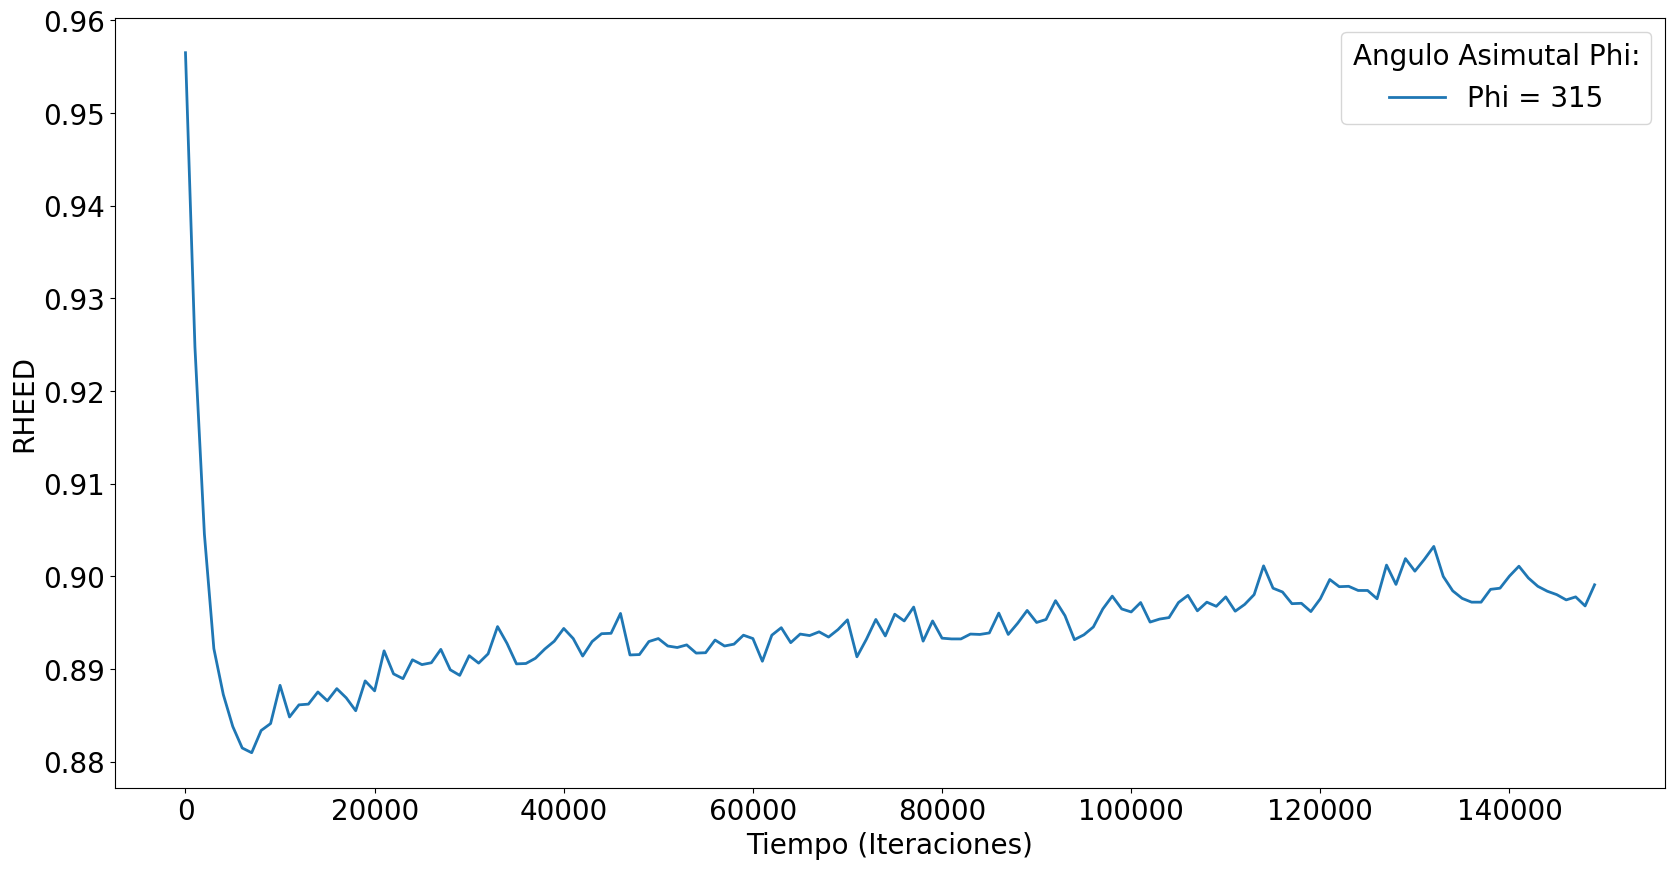

In [15]:
R = rheed
R_norm = R.copy()
max_val = R.drop(columns='t').values.max()

# Normalizar todas las columnas excepto 't'

plt.figure(figsize=(20,10))
#x = range(len(R))
for i in [0,45,90,135,180,225,270,315]:
    plt.figure(figsize=(20,10))
    plt.plot(R['t'],R[F'{i}'],label=f'Phi = {i}',linewidth=2)
    #plt.ylim(min(R[F'{i}']) - 0.01,0.9)
    #plt.ylim(0.56,0.6)
    #plt.show()
#plt.xlim(0,15000)
#plt.ylim(0.56,0.575)
#plt.title(f"Intensidad RHEED del crecimiento de GaAs limado hacia +X (Ultima capa en Ga)\nProbabilidades de deposicion: Ga = {prob_crecimiento_Ga}, As = {prob_crecimiento_As}",fontsize=20)
plt.legend(title='Angulo Asimutal Phi:',fontsize=20)
plt.xlabel('Tiempo (Iteraciones)',fontsize=20)
plt.ylabel("RHEED",fontsize=20)
plt.show()

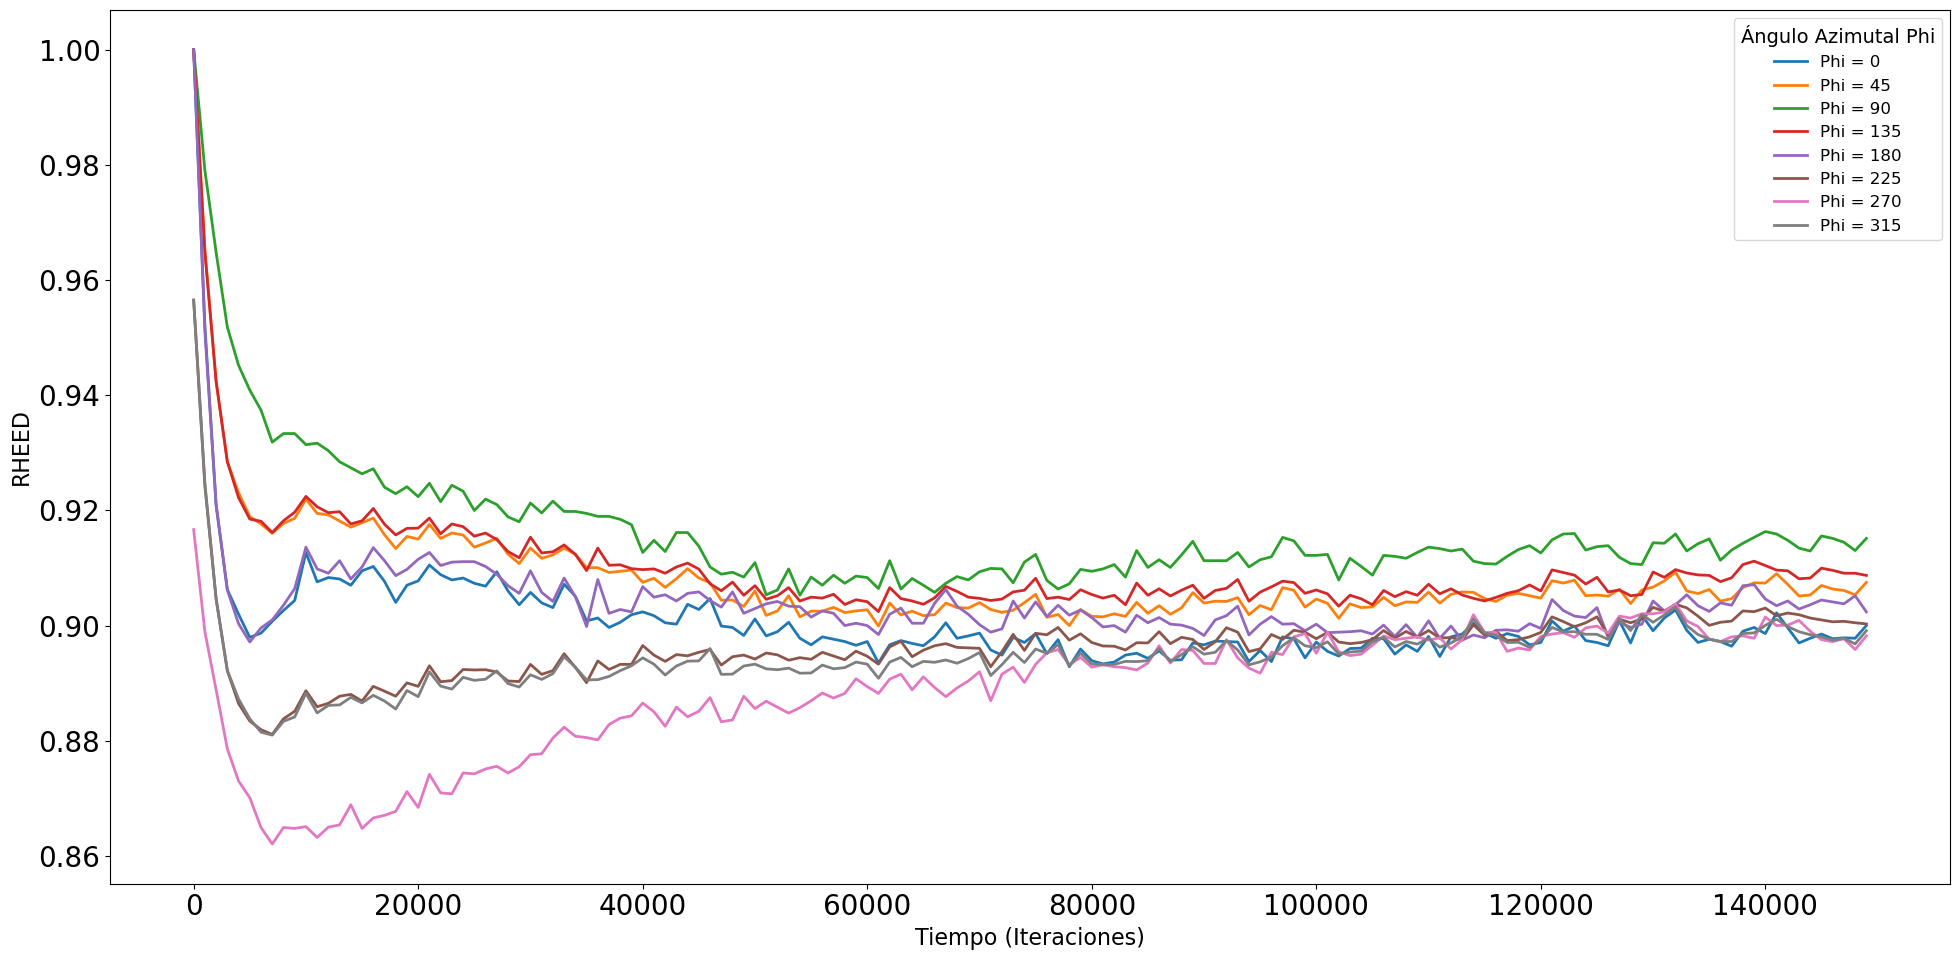

In [16]:
import matplotlib.pyplot as plt

# Normalización (ya asumida)
R_norm = R.copy()
max_val = R.drop(columns='t').values.max()
for col in R_norm.columns:
    if col != 't':
        R_norm[col] /= max_val

# Plot en una sola figura
plt.figure(figsize=(20, 10))

# Lista de ángulos azimutales
angles = [0, 45, 90, 135, 180, 225, 270, 315]
#colors = plt.cm.plasma(np.linspace(0, 1, len(angles)))  # Colores suaves y distinguibles

# Graficar todas las curvas
for i, angle in enumerate(angles):
    plt.plot(R_norm['t'], R_norm[f'{angle}'], label=f'Phi = {angle}', linewidth=2)

# Estética del gráfico
plt.title('')
plt.xlabel('Tiempo (Iteraciones)', fontsize=16)
plt.ylabel('RHEED', fontsize=16)
plt.legend(title='Ángulo Azimutal Phi', fontsize=12, title_fontsize=14)
#plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
#A = (2.7181)**(*(10))
#-math.log(1)*(1/(A))
A = (2.7182818284)**((10**1)*(-5))
B = 1
C = (2.7182818284)**((10**1)*(-1))
D = (2.7182818284)**((10**1)*(-6))
-np.log(0.001)*(1/(A)),-np.log(0.5)*(1/(B)),-np.log(0.5)*(1/(C)),-np.log(0.00000000001)*(1/(D))

In [9]:
import math
-math.log(0.000001)/((2.7182818284)**(-60)),-math.log(0.00000001)/((2.7182818284)**(-5)),-math.log(0.000001)/((2.7182818284)**(-60))

(1.5777415130709192e+27, 2733.871421733052, 1.5777415130709192e+27)

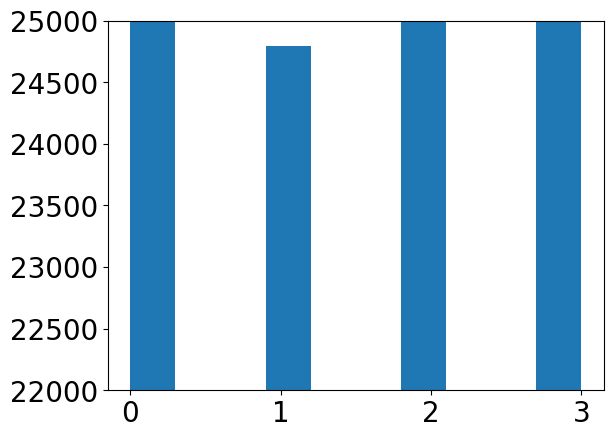

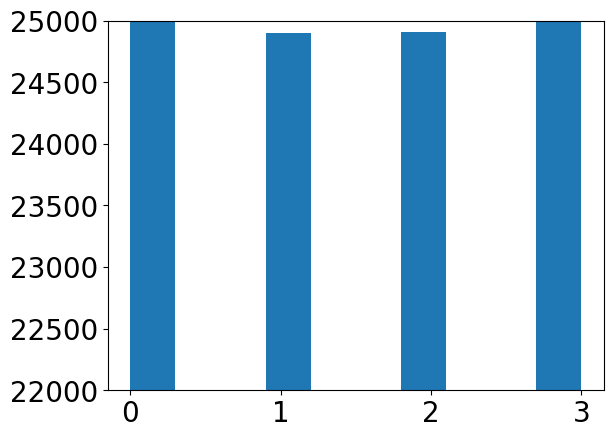

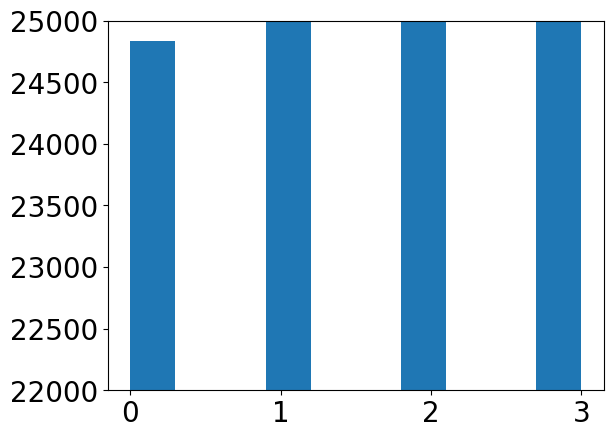

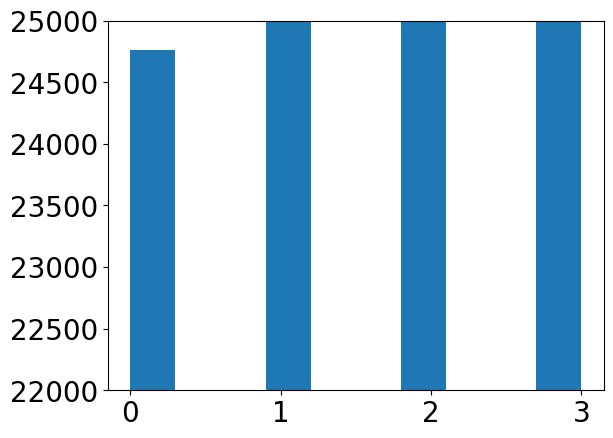

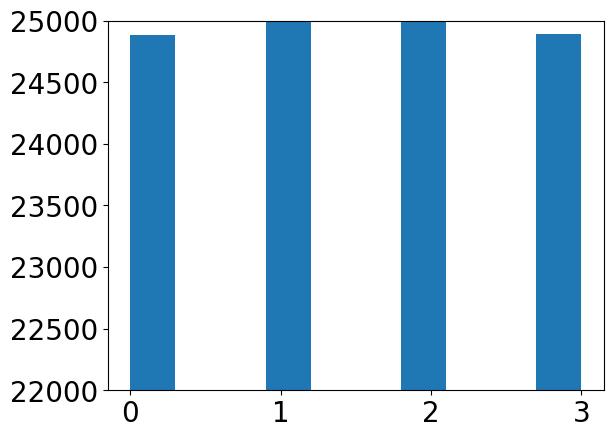

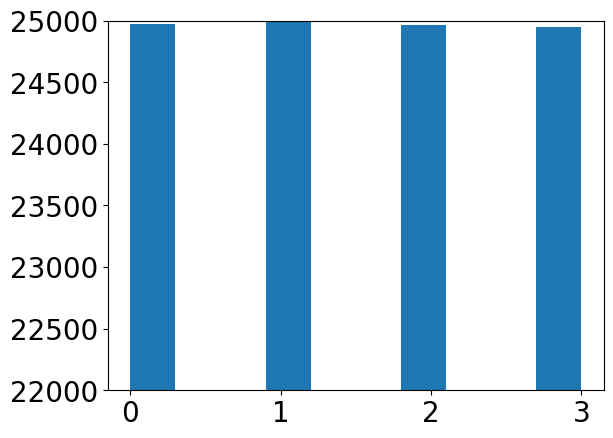

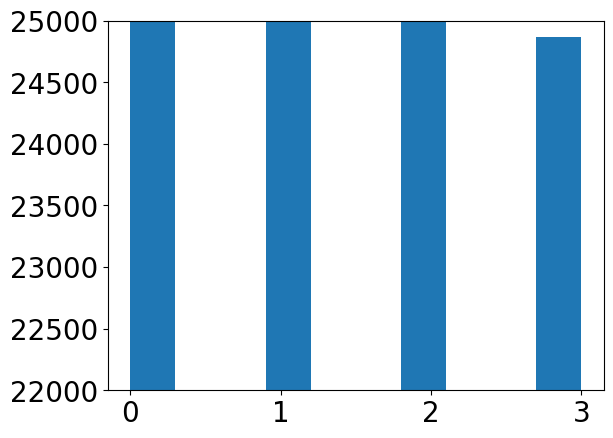

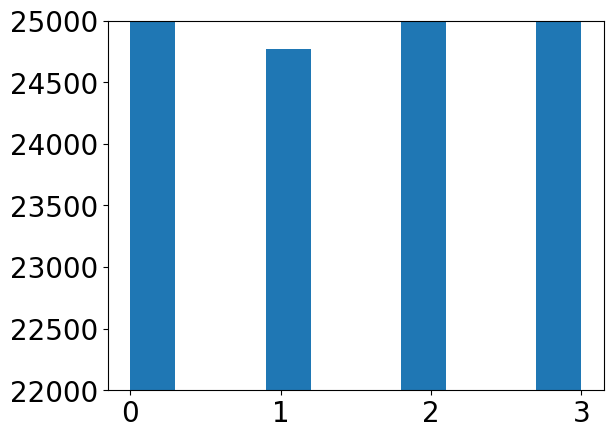

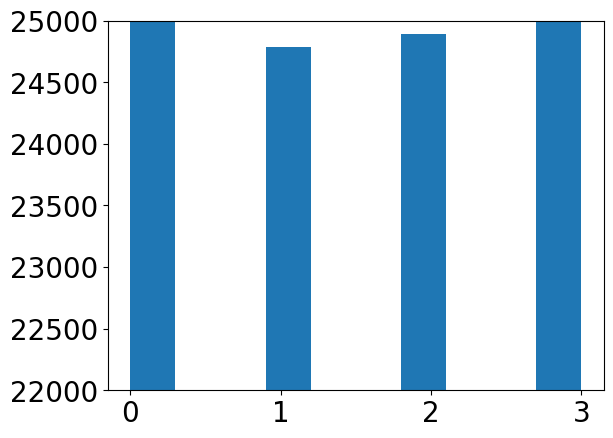

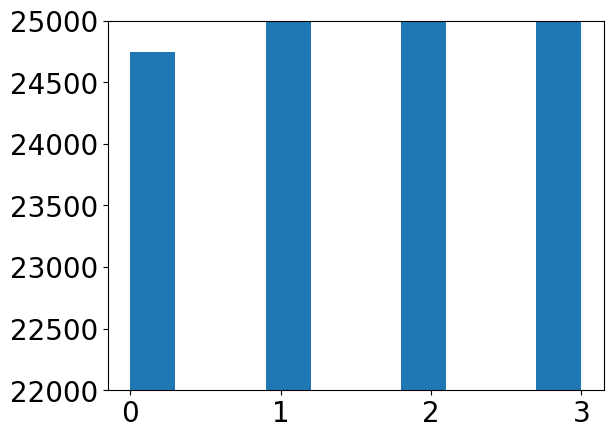

In [51]:

for j in range(5):
    array = []
    for i in range(100000):
        n = int( np.random.rand() *4) 
      #  n += int( np.random.rand() *4) 
        array.append((n)%4)
    plt.hist(array)
    plt.ylim(22000,25000)
    plt.show()